CHECK IF DATA EXISTS

In [1]:
import os

# Put your EXACT Windows path here (use forward slashes '/')
DATASET_PATH = "H:/.shortcut-targets-by-id/1pFPnn7lbpxWVfOmrDEyvHxXp0_6GFB90/Students/Machine 1/machine_data/Abnormal"

# Test 1: Does Python see the warehouse?
if os.path.exists(DATASET_PATH):
    print("✅ SUCCESS: Python found the warehouse!")
    
    # Test 2: What is inside?
    machines = os.listdir(DATASET_PATH)
    print(f"📦 Inside the warehouse, I see: {machines}")
else:
    print("❌ ERROR: Python cannot find that path. Check your spelling!")

✅ SUCCESS: Python found the warehouse!
📦 Inside the warehouse, I see: ['2170.wav', '2182.wav', '2169.wav', '2163.wav', '2179.wav', '2165.wav', '2178.wav', '2175.wav', '2173.wav', '2168.wav', '2187.wav', '2189.wav', '2205.wav', '2191.wav', '2190.wav', '2194.wav', '2201.wav', '2207.wav', '2196.wav', '2192.wav', '2199.wav', '2188.wav', '2193.wav', '2195.wav', '2200.wav', '2206.wav', '2203.wav', '2198.wav', '2202.wav', '2197.wav', '2204.wav', '2209.wav', '2208.wav', '2211.wav', '2210.wav', '2215.wav', '2216.wav', '2233.wav', '2236.wav', '2222.wav', '2234.wav', '2223.wav', '2235.wav', '2230.wav', '2237.wav', '2213.wav', '2228.wav', '2227.wav', '2221.wav', '2214.wav', '2224.wav', '2232.wav', '2212.wav', '2218.wav', '2238.wav', '2229.wav', '2219.wav', '2220.wav', '2225.wav', '2217.wav', '2226.wav', '2231.wav', '2245.wav', '2249.wav', '2248.wav', '2261.wav', '2244.wav', '2258.wav', '2240.wav', '2260.wav', '2242.wav', '2259.wav', '2239.wav', '2250.wav', '2247.wav', '2254.wav', '2256.wav', '2251

RAW DATA VISUALIZATION FOR ONE FILE (TEST)

C:\Users\Youssef\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Original Sample Rate: 48000 Hz


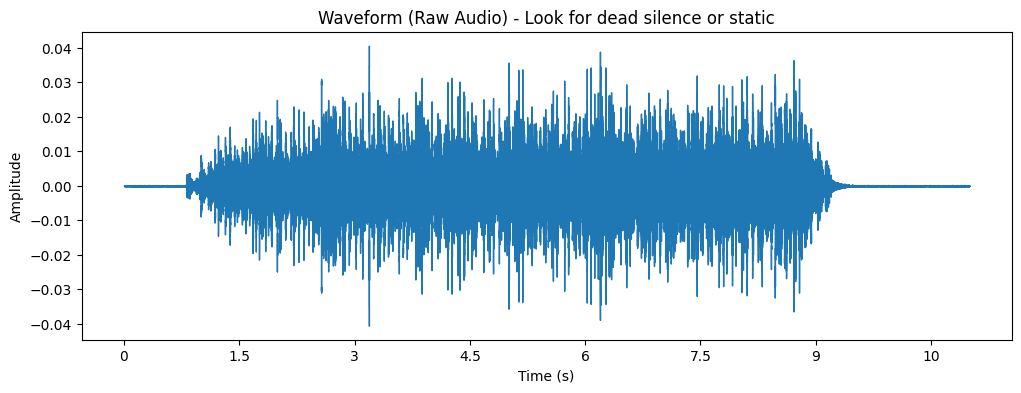

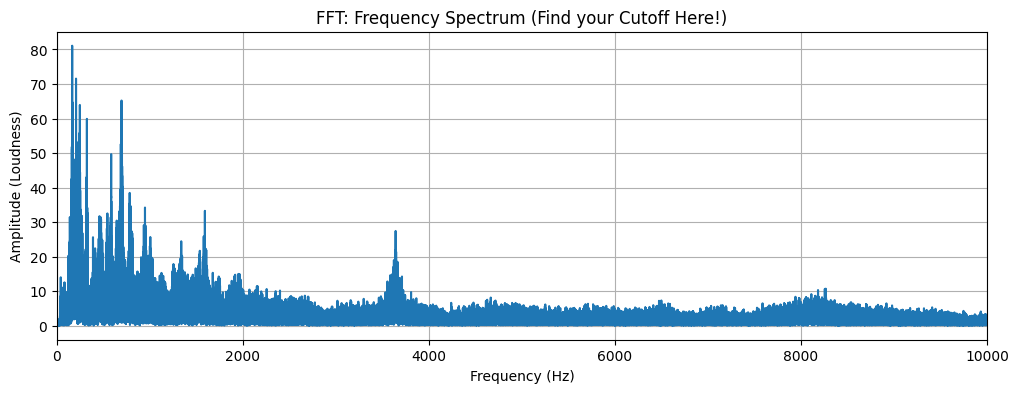

In [2]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft

# 1. Load the RAW audio (Notice sr=None. We don't want to resample yet!)
file_path = "H:/.shortcut-targets-by-id/1pFPnn7lbpxWVfOmrDEyvHxXp0_6GFB90/Students/Machine 1/machine_data/Abnormal/2170.wav"
audio, sr = librosa.load(file_path, sr=None) 

print(f"Original Sample Rate: {sr} Hz")

# --- PLOT 1: The Waveform (Time Domain) ---
plt.figure(figsize=(12, 4))
librosa.display.waveshow(audio, sr=sr)
plt.title('Waveform (Raw Audio) - Look for dead silence or static')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

# --- PLOT 2: The FFT (Frequency Domain) - THE MOST IMPORTANT ONE ---
spectrum_fft = fft(audio)
frequencies = np.fft.fftfreq(len(spectrum_fft), 1 / sr)

# We only care about the positive half of the frequencies
half_point = len(frequencies) // 2
pos_freqs = frequencies[:half_point]
pos_amps = np.abs(spectrum_fft[:half_point])

plt.figure(figsize=(12, 4))
plt.plot(pos_freqs, pos_amps)
plt.title('FFT: Frequency Spectrum (Find your Cutoff Here!)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (Loudness)')
plt.xlim(0, 10000) # Zoom in on the 0 to 10k range
plt.grid(True)
plt.show()

MEAN SPECTRAL DATA FOR A SAMPLE (EG.100 FILES)

Analyzing 100 files in Normal...
Analyzing 100 files in Abnormal...


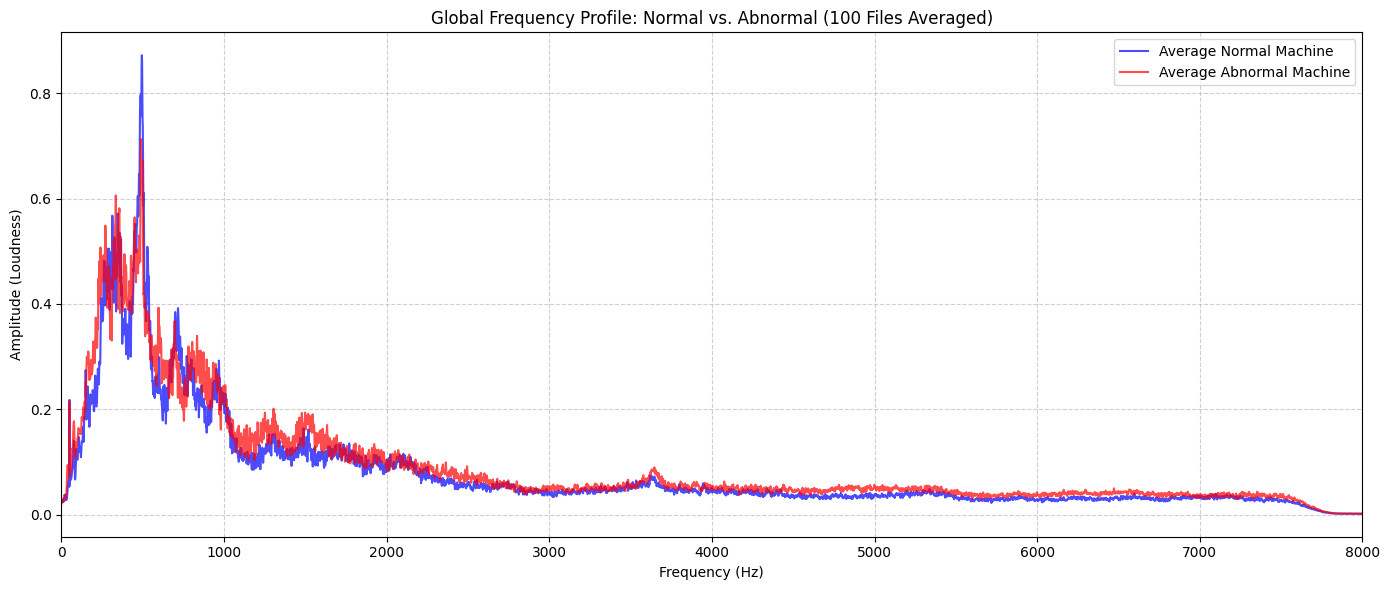

In [3]:
import librosa
import numpy as np
import os
import matplotlib.pyplot as plt

def compute_average_fft(folder_path, num_files=100, target_sr=16000):
    """Calculates the average frequency profile for a whole folder of audio."""
    audio_files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
    
    # Take a random sample so it runs fast but gives a perfect overview
    np.random.shuffle(audio_files)
    audio_files = audio_files[:num_files]
    
    all_fft_amps = []
    print(f"Analyzing {len(audio_files)} files in {os.path.basename(folder_path)}...")
    
    for filename in audio_files:
        file_path = os.path.join(folder_path, filename)
        
        # Load and force to exactly 1 second (16000 samples) 
        # This is strictly required so all FFT arrays are the exact same size for averaging
        y, sr = librosa.load(file_path, sr=target_sr, duration=1.0)
        if len(y) < target_sr:
            y = np.pad(y, (0, target_sr - len(y)))
            
        # Compute FFT
        spectrum = np.abs(np.fft.fft(y))
        
        # We only need the positive half of the frequencies
        half_point = len(spectrum) // 2
        pos_amps = spectrum[:half_point]
        
        all_fft_amps.append(pos_amps)
        
    # Stack the 100 arrays on top of each other and calculate the vertical average
    avg_amps = np.mean(all_fft_amps, axis=0)
    
    # Calculate the frequency labels for the X-axis
    freqs = np.fft.fftfreq(target_sr, 1/target_sr)[:half_point]
    
    return freqs, avg_amps

# --- RUN THE ENGINE ---

# 1. Set your paths
normal_dir = "H:/.shortcut-targets-by-id/1pFPnn7lbpxWVfOmrDEyvHxXp0_6GFB90/Students/Machine 1/machine_data/Normal"
abnormal_dir = "H:/.shortcut-targets-by-id/1pFPnn7lbpxWVfOmrDEyvHxXp0_6GFB90/Students/Machine 1/machine_data/Abnormal"

# 2. Get the averages
freqs, normal_avg = compute_average_fft(normal_dir, num_files=100)
_, abnormal_avg = compute_average_fft(abnormal_dir, num_files=100)

# 3. Plot the Global Comparison
plt.figure(figsize=(14, 6))

# Plot Normal in Blue
plt.plot(freqs, normal_avg, label='Average Normal Machine', color='blue', alpha=0.7)
# Plot Abnormal in Red
plt.plot(freqs, abnormal_avg, label='Average Abnormal Machine', color='red', alpha=0.7)

plt.title('Global Frequency Profile: Normal vs. Abnormal (100 Files Averaged)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (Loudness)')

# The Nyquist limit for 16000 Hz is 8000 Hz, so we zoom in on that range
plt.xlim(0, 8000) 

# Add a subtle grid to make reading the X-axis numbers easier
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

FULL CHECK OF THE FREQUENCY AND AMPLITUDE USING ABSOLUTE (AVERAGE ENERGY ENVELOPE)

Analyzing 100 files in Normal...
Analyzing 100 files in Abnormal...


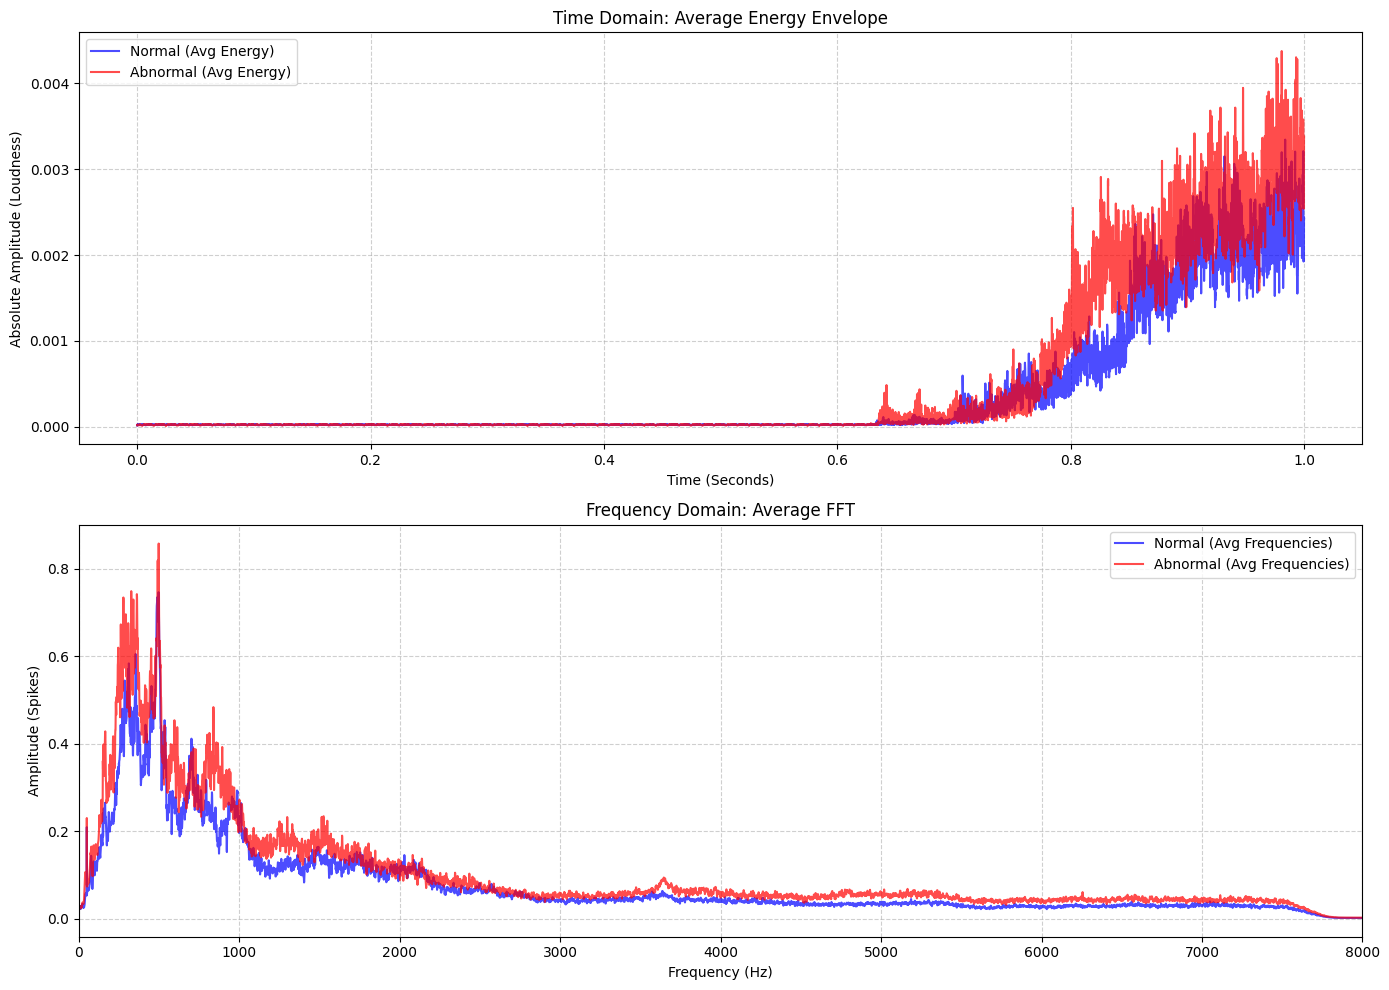

In [4]:
import librosa
import numpy as np
import os
import matplotlib.pyplot as plt

def compute_average_profiles(folder_path, num_files=150, target_sr=16000):
    """Calculates both the average frequency and average time profiles."""
    audio_files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
    
    np.random.shuffle(audio_files)
    audio_files = audio_files[:num_files]
    
    all_fft_amps = []
    all_time_amps = []
    
    print(f"Analyzing {len(audio_files)} files in {os.path.basename(folder_path)}...")
    
    for filename in audio_files:
        file_path = os.path.join(folder_path, filename)
        
        y, sr = librosa.load(file_path, sr=target_sr, duration=1.0)
        if len(y) < target_sr:
            y = np.pad(y, (0, target_sr - len(y)))
            
        # --- 1. FFT (Frequency) Processing ---
        spectrum = np.abs(np.fft.fft(y))
        half_point = len(spectrum) // 2
        pos_amps = spectrum[:half_point]
        all_fft_amps.append(pos_amps)
        
        # --- 2. Time (Amplitude) Processing ---
        # Crucial: Take the absolute value so waves don't cancel each other out!
        all_time_amps.append(np.abs(y))
        
    # Calculate the averages
    avg_fft = np.mean(all_fft_amps, axis=0)
    avg_time = np.mean(all_time_amps, axis=0)
    
    # Calculate X-axis labels
    freqs = np.fft.fftfreq(target_sr, 1/target_sr)[:half_point]
    times = np.linspace(0, 1.0, target_sr) # Creates a time axis from 0s to 1s
    
    return freqs, avg_fft, times, avg_time

# --- RUN THE ENGINE ---

normal_dir = "H:/.shortcut-targets-by-id/1pFPnn7lbpxWVfOmrDEyvHxXp0_6GFB90/Students/Machine 1/machine_data/Normal"
abnormal_dir = "H:/.shortcut-targets-by-id/1pFPnn7lbpxWVfOmrDEyvHxXp0_6GFB90/Students/Machine 1/machine_data/Abnormal"

# Get data for both
norm_freqs, norm_fft_avg, norm_times, norm_time_avg = compute_average_profiles(normal_dir, num_files=100)
ab_freqs, ab_fft_avg, ab_times, ab_time_avg = compute_average_profiles(abnormal_dir, num_files=100)

# --- PLOT BOTH GRAPHS ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# 1. The Time Graph (Amplitude Envelope)
ax1.plot(norm_times, norm_time_avg, label='Normal (Avg Energy)', color='blue', alpha=0.7)
ax1.plot(ab_times, ab_time_avg, label='Abnormal (Avg Energy)', color='red', alpha=0.7)
ax1.set_title('Time Domain: Average Energy Envelope')
ax1.set_xlabel('Time (Seconds)')
ax1.set_ylabel('Absolute Amplitude (Loudness)')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# 2. The Frequency Graph (FFT)
ax2.plot(norm_freqs, norm_fft_avg, label='Normal (Avg Frequencies)', color='blue', alpha=0.7)
ax2.plot(ab_freqs, ab_fft_avg, label='Abnormal (Avg Frequencies)', color='red', alpha=0.7)
ax2.set_title('Frequency Domain: Average FFT')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Amplitude (Spikes)')
ax2.set_xlim(0, 8000) # Nyquist limit for 16kHz
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

PROBLEM WITH THE AVERAGE ENERGY ENVELOPE HERE IS THAT IT TAKES THE FIRST ONE SECOND SAMPLE OF THE FILES 

WE WILL NOW TAKE THE LONGEST FILE AND MAKE THIS THE DURATION AND AVERAGE ON IT SO WE KNOW WHERE TO TRIM

Analyzing 100 files in Normal...
  -> Longest file is 11.00 seconds.
Analyzing 100 files in Abnormal...
  -> Longest file is 11.00 seconds.


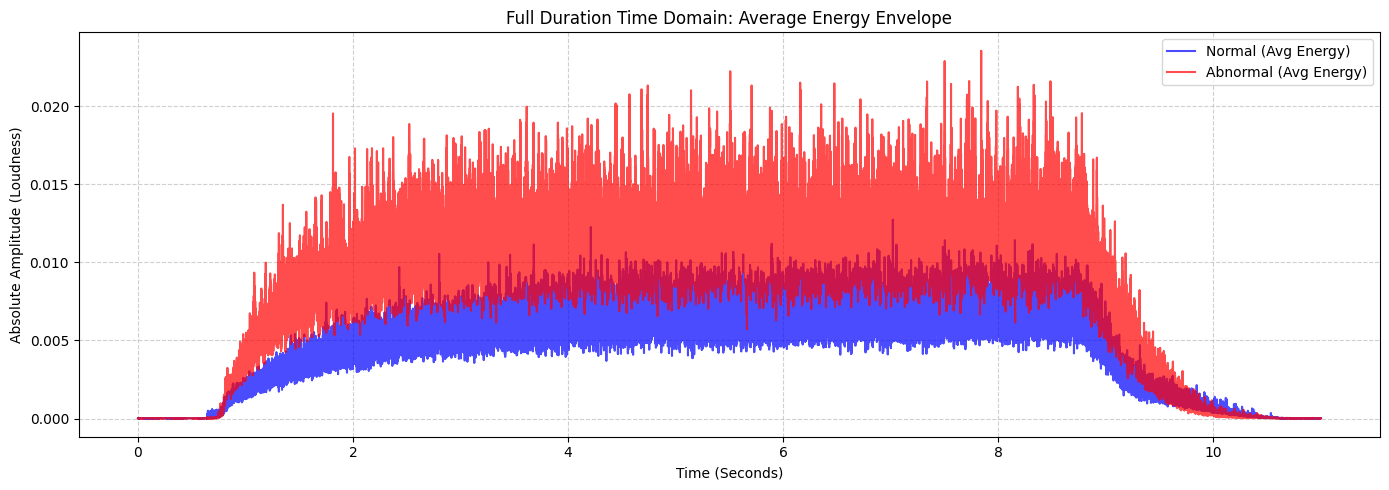

In [5]:
import librosa
import numpy as np
import os
import matplotlib.pyplot as plt

def compute_full_energy_envelope(folder_path, num_files=100, target_sr=16000):
    """Calculates the average time profile for the ENTIRE duration of the files."""
    audio_files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
    
    np.random.shuffle(audio_files)
    audio_files = audio_files[:num_files]
    
    all_time_amps = []
    print(f"Analyzing {len(audio_files)} files in {os.path.basename(folder_path)}...")
    
    for filename in audio_files:
        file_path = os.path.join(folder_path, filename)
        
        # Notice: NO duration limit here! We load the whole file.
        y, sr = librosa.load(file_path, sr=target_sr)
        
        # Take absolute value for the energy envelope
        all_time_amps.append(np.abs(y))
        
    # Find the maximum length among all the files we loaded
    max_length = max([len(y) for y in all_time_amps])
    print(f"  -> Longest file is {max_length / target_sr:.2f} seconds.")
    
    # Pad all files with zeros at the end so they match the max_length
    padded_amps = []
    for y in all_time_amps:
        if len(y) < max_length:
            y_padded = np.pad(y, (0, max_length - len(y)))
            padded_amps.append(y_padded)
        else:
            padded_amps.append(y)
            
    # Now we can safely average them
    avg_time = np.mean(padded_amps, axis=0)
    
    # Create the X-axis for the full duration
    times = np.linspace(0, max_length / target_sr, max_length)
    
    return times, avg_time

# --- RUN THE ENGINE ---

normal_dir = "H:/.shortcut-targets-by-id/1pFPnn7lbpxWVfOmrDEyvHxXp0_6GFB90/Students/Machine 1/machine_data/Normal"
abnormal_dir = "H:/.shortcut-targets-by-id/1pFPnn7lbpxWVfOmrDEyvHxXp0_6GFB90/Students/Machine 1/machine_data/Abnormal"

norm_times, norm_time_avg = compute_full_energy_envelope(normal_dir, num_files=100)
ab_times, ab_time_avg = compute_full_energy_envelope(abnormal_dir, num_files=100)

# --- PLOT THE GRAPH ---
plt.figure(figsize=(14, 5))

# Plot both lines
plt.plot(norm_times, norm_time_avg, label='Normal (Avg Energy)', color='blue', alpha=0.7)
plt.plot(ab_times, ab_time_avg, label='Abnormal (Avg Energy)', color='red', alpha=0.7)

plt.title('Full Duration Time Domain: Average Energy Envelope')
plt.xlabel('Time (Seconds)')
plt.ylabel('Absolute Amplitude (Loudness)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

ALL THESE ARE HARDCODED THRESHHOLDS I REALIZED WE NEED TO CREATE A DYNAMIC AUDIO SIGNAL PROCESSING CODE A (DYNAMIC DISTRIBUTION ANALYZER)

Dynamically analyzing 100 files in Normal...
Dynamically analyzing 100 files in Abnormal...


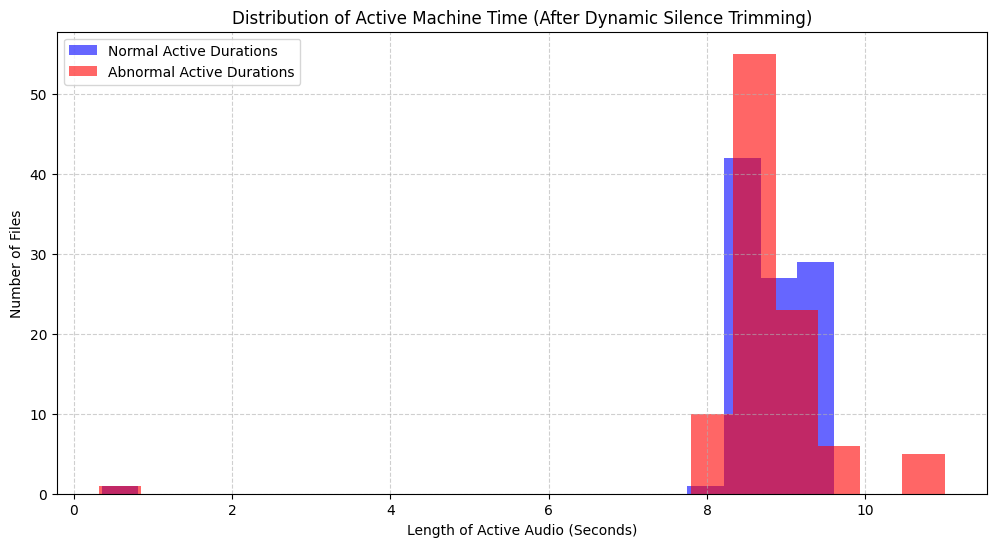

In [6]:
import librosa
import os
import numpy as np
import matplotlib.pyplot as plt

def analyze_active_durations(folder_path, top_db_threshold=20, num_files=100):
    """
    Dynamically trims silence from each file and calculates the length 
    of the actual mechanical action.
    """
    audio_files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
    np.random.shuffle(audio_files)
    audio_files = audio_files[:num_files]
    
    active_durations = []
    
    print(f"Dynamically analyzing {len(audio_files)} files in {os.path.basename(folder_path)}...")
    
    for filename in audio_files:
        file_path = os.path.join(folder_path, filename)
        
        # Load the full file
        y, sr = librosa.load(file_path, sr=16000)
        
        # --- THE DYNAMIC TRIMMER ---
        # top_db=20 means: "If a sound is 20 decibels quieter than the loudest 
        # part of this specific file, consider it silence and cut it."
        y_trimmed, index = librosa.effects.trim(y, top_db=top_db_threshold)
        
        # Calculate how long the trimmed "active" audio is in seconds
        active_length_seconds = len(y_trimmed) / sr
        active_durations.append(active_length_seconds)
        
    return active_durations

# --- RUN THE ENGINE ---
normal_dir = "H:/.shortcut-targets-by-id/1pFPnn7lbpxWVfOmrDEyvHxXp0_6GFB90/Students/Machine 1/machine_data/Normal"
abnormal_dir = "H:/.shortcut-targets-by-id/1pFPnn7lbpxWVfOmrDEyvHxXp0_6GFB90/Students/Machine 1/machine_data/Abnormal"

# You might need to adjust top_db. 20 is a standard starting point. 
# If it's cutting off too much machine noise, increase it to 30.
norm_durations = analyze_active_durations(normal_dir, top_db_threshold=20, num_files=100)
ab_durations = analyze_active_durations(abnormal_dir, top_db_threshold=20, num_files=100)

# --- PLOT THE DISTRIBUTION (HISTOGRAM) ---
plt.figure(figsize=(12, 6))

# We use a histogram to see the distribution of lengths
plt.hist(norm_durations, bins=20, alpha=0.6, color='blue', label='Normal Active Durations')
plt.hist(ab_durations, bins=20, alpha=0.6, color='red', label='Abnormal Active Durations')

plt.title('Distribution of Active Machine Time (After Dynamic Silence Trimming)')
plt.xlabel('Length of Active Audio (Seconds)')
plt.ylabel('Number of Files')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [ ]:
import librosa
import os
import numpy as np
import matplotlib.pyplot as plt

def analyze_active_durations(folder_path, top_db_threshold=26, num_files=100):
    """
    Dynamically trims silence from each file and calculates the length 
    of the actual mechanical action.
    """
    audio_files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
    np.random.shuffle(audio_files)
    audio_files = audio_files[:num_files]
    
    active_durations = []
    
    print(f"Dynamically analyzing {len(audio_files)} files in {os.path.basename(folder_path)}...")
    
    for filename in audio_files:
        file_path = os.path.join(folder_path, filename)
        
        # Load the full file
        y, sr = librosa.load(file_path, sr=16000)
        
        # --- THE DYNAMIC TRIMMER ---
        # top_db=26 means: "If a sound is 26 decibels quieter than the loudest 
        # part of this specific file, consider it silence and cut it."
        y_trimmed, index = librosa.effects.trim(y, top_db=top_db_threshold)
        
        # Calculate how long the trimmed "active" audio is in seconds
        active_length_seconds = len(y_trimmed) / sr
        active_durations.append(active_length_seconds)
        
    return active_durations

# --- RUN THE ENGINE ---
normal_dir = "H:/.shortcut-targets-by-id/1pFPnn7lbpxWVfOmrDEyvHxXp0_6GFB90/Students/Machine 1/machine_data/Normal"
abnormal_dir = "H:/.shortcut-targets-by-id/1pFPnn7lbpxWVfOmrDEyvHxXp0_6GFB90/Students/Machine 1/machine_data/Abnormal"

# You might need to adjust top_db. 26 is a standard starting point. 
# If it's cutting off too much machine noise, increase it to 30.
norm_durations = analyze_active_durations(normal_dir, top_db_threshold=26, num_files=100)
ab_durations = analyze_active_durations(abnormal_dir, top_db_threshold=26, num_files=100)

# --- PLOT THE DISTRIBUTION (HISTOGRAM) ---
plt.figure(figsize=(12, 6))

# We use a histogram to see the distribution of lengths
plt.hist(norm_durations, bins=20, alpha=0.6, color='blue', label='Normal Active Durations')
plt.hist(ab_durations, bins=20, alpha=0.6, color='red', label='Abnormal Active Durations')

plt.title('Distribution of Active Machine Time (After Dynamic Silence Trimming)')
plt.xlabel('Length of Active Audio (Seconds)')
plt.ylabel('Number of Files')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

Dynamically analyzing 100 files in Normal...


KeyboardInterrupt: 

AFTER SEEING THAT A 26DB TRIM (5%) GETS BETTER RESULTS AND THAT THE CUTOFF FREQUENCY SHOULD BE AROUND 4000HZ I AM CREATING A DEMO PIPELINE FIRST CUTTING OFF THE FREQUENCY THEN SEEING THE ACTIVE MACHINE TIME THEN TRIMMING
FOR (150 SAMPLES)

Processing 150 files in Normal...
 -> 1. Applying 4000Hz Low-Pass Filter
 -> 2. Trimming silence at 26dB
Processing 150 files in Abnormal...
 -> 1. Applying 4000Hz Low-Pass Filter
 -> 2. Trimming silence at 26dB


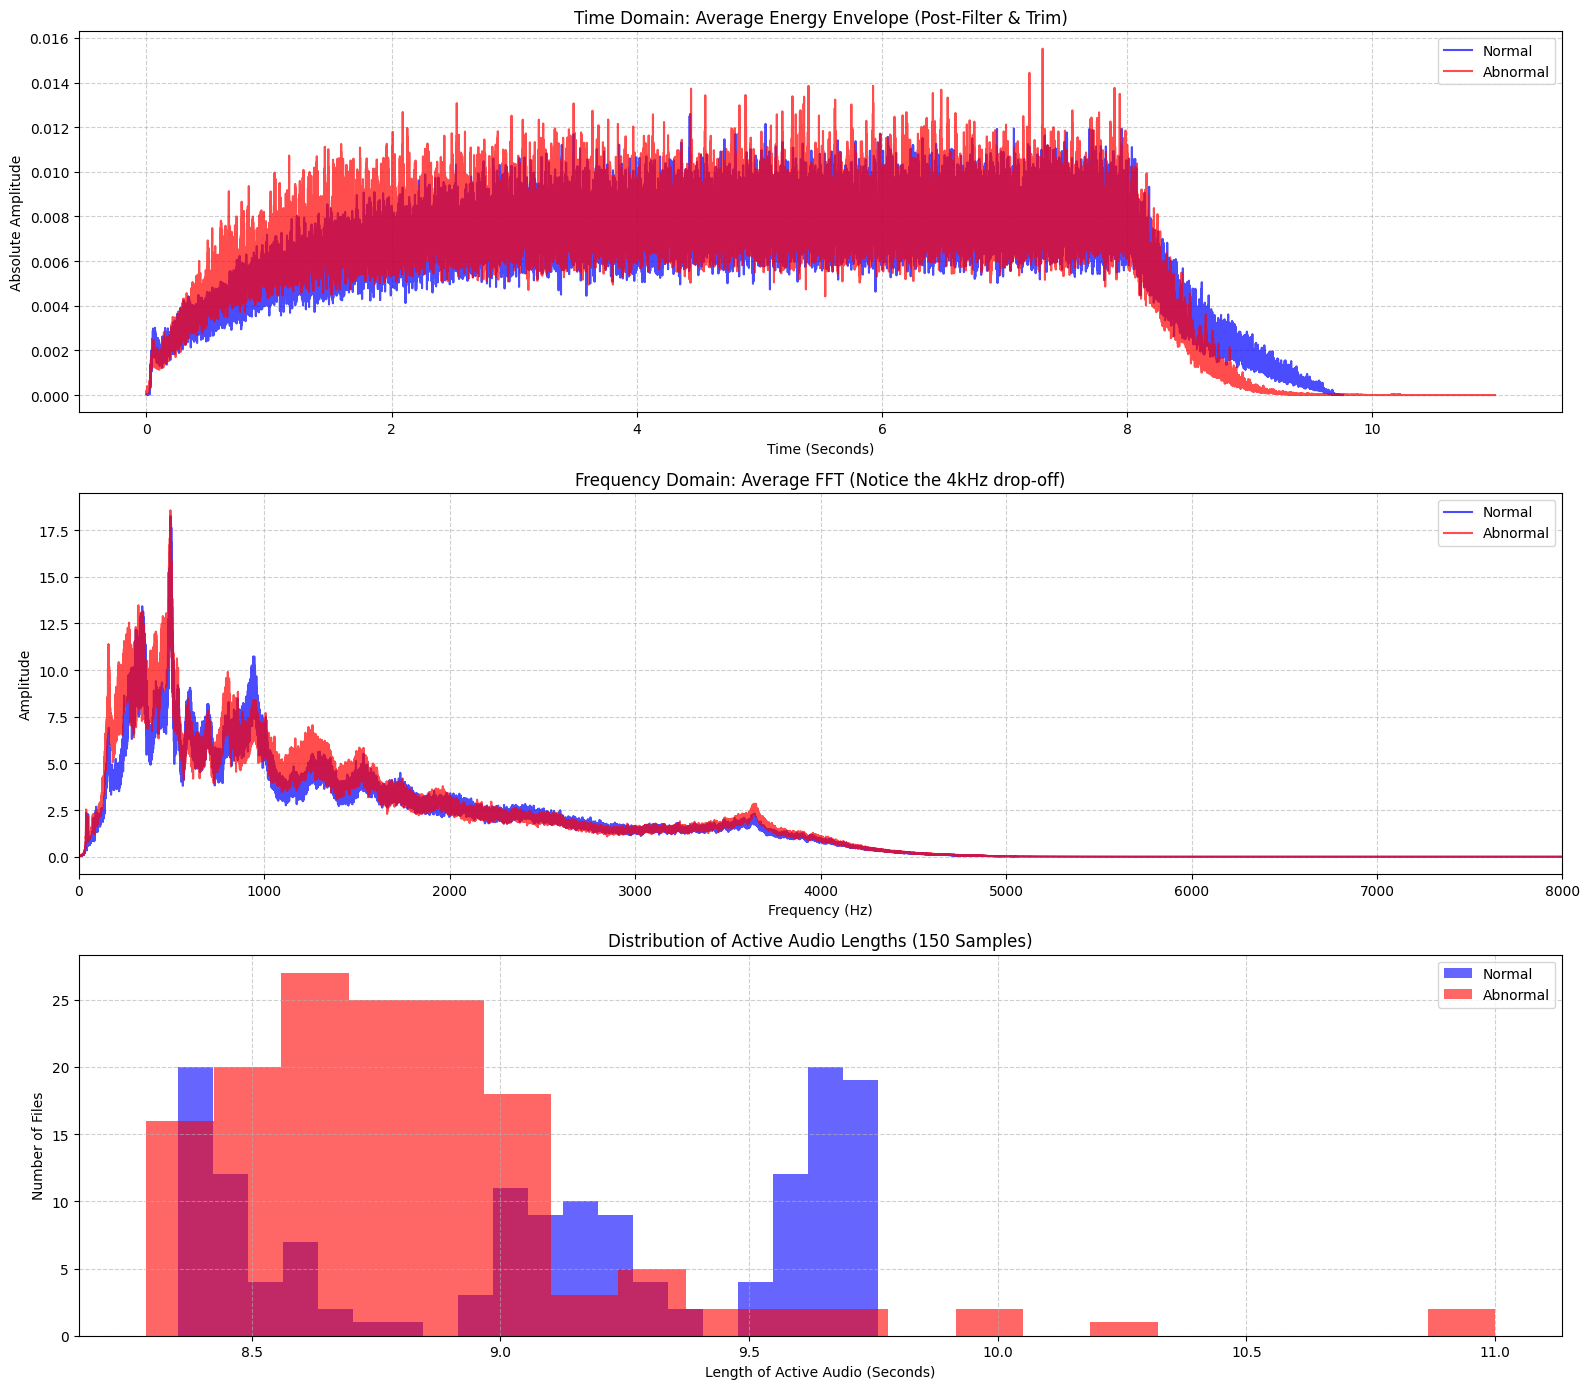

In [8]:
import librosa
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# --- 1. THE LOW-PASS FILTER ---
def apply_lowpass_filter(data, cutoff=4000, sr=16000, order=5):
    """Applies a Butterworth low-pass filter to remove frequencies above the cutoff."""
    nyquist = 0.5 * sr
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    # filtfilt applies the filter forward and backward to prevent phase shifting
    filtered_data = filtfilt(b, a, data) 
    return filtered_data

# --- 2. THE MASTER ANALYSIS ENGINE ---
def analyze_filtered_and_trimmed(folder_path, cutoff=4000, top_db=26, num_files=150, sr=16000):
    audio_files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
    
    # Randomly select 150 files so we aren't waiting forever
    np.random.shuffle(audio_files)
    audio_files = audio_files[:num_files]
    
    active_durations = []
    processed_audios = []
    
    print(f"Processing {len(audio_files)} files in {os.path.basename(folder_path)}...")
    print(f" -> 1. Applying {cutoff}Hz Low-Pass Filter")
    print(f" -> 2. Trimming silence at {top_db}dB")
    
    for filename in audio_files:
        file_path = os.path.join(folder_path, filename)
        
        # Load full file
        y, _ = librosa.load(file_path, sr=sr)
        
        # STEP 1: Filter out the high-frequency garbage first
        y_filtered = apply_lowpass_filter(y, cutoff=cutoff, sr=sr)
        
        # STEP 2: Trim the silence based on the clean, filtered audio
        y_trimmed, _ = librosa.effects.trim(y_filtered, top_db=top_db)
        
        # Save duration and processed audio
        active_durations.append(len(y_trimmed) / sr)
        processed_audios.append(y_trimmed)
        
    # --- AVERAGING PREP ---
    # To average the arrays, we pad them to match the longest trimmed file in this batch
    max_len = max([len(y) for y in processed_audios])
    
    all_time_amps = []
    all_fft_amps = []
    
    for y in processed_audios:
        y_padded = np.pad(y, (0, max_len - len(y)))
        
        # Energy Envelope (Absolute Amplitude)
        all_time_amps.append(np.abs(y_padded))
        
        # FFT (Frequency Profile)
        spectrum = np.abs(np.fft.fft(y_padded))
        all_fft_amps.append(spectrum[:len(spectrum)//2])
        
    # Calculate Averages
    avg_time = np.mean(all_time_amps, axis=0)
    avg_fft = np.mean(all_fft_amps, axis=0)
    
    # Calculate X-Axes
    times = np.linspace(0, max_len / sr, max_len)
    freqs = np.fft.fftfreq(max_len, 1/sr)[:len(spectrum)//2]
    
    return times, avg_time, freqs, avg_fft, active_durations

# --- 3. RUN THE ENGINE ---
normal_dir = "H:/.shortcut-targets-by-id/1pFPnn7lbpxWVfOmrDEyvHxXp0_6GFB90/Students/Machine 1/machine_data/Normal"
abnormal_dir = "H:/.shortcut-targets-by-id/1pFPnn7lbpxWVfOmrDEyvHxXp0_6GFB90/Students/Machine 1/machine_data/Abnormal"

# Executing on 150 samples per class
norm_times, norm_time_avg, norm_freqs, norm_fft_avg, norm_durations = analyze_filtered_and_trimmed(normal_dir, num_files=150)
ab_times, ab_time_avg, ab_freqs, ab_fft_avg, ab_durations = analyze_filtered_and_trimmed(abnormal_dir, num_files=150)

# --- 4. THE ULTIMATE DASHBOARD ---
fig = plt.figure(figsize=(16, 14))

# Graph A: Time Domain
ax1 = plt.subplot(3, 1, 1)
ax1.plot(norm_times, norm_time_avg, label='Normal', color='blue', alpha=0.7)
ax1.plot(ab_times, ab_time_avg, label='Abnormal', color='red', alpha=0.7)
ax1.set_title('Time Domain: Average Energy Envelope (Post-Filter & Trim)')
ax1.set_xlabel('Time (Seconds)')
ax1.set_ylabel('Absolute Amplitude')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Graph B: Frequency Domain (FFT)
ax2 = plt.subplot(3, 1, 2)
ax2.plot(norm_freqs, norm_fft_avg, label='Normal', color='blue', alpha=0.7)
ax2.plot(ab_freqs, ab_fft_avg, label='Abnormal', color='red', alpha=0.7)
ax2.set_title('Frequency Domain: Average FFT (Notice the 4kHz drop-off)')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Amplitude')
ax2.set_xlim(0, 8000)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

# Graph C: Distribution of Lengths
ax3 = plt.subplot(3, 1, 3)
ax3.hist(norm_durations, bins=20, alpha=0.6, color='blue', label='Normal')
ax3.hist(ab_durations, bins=20, alpha=0.6, color='red', label='Abnormal')
ax3.set_title('Distribution of Active Audio Lengths (150 Samples)')
ax3.set_xlabel('Length of Active Audio (Seconds)')
ax3.set_ylabel('Number of Files')
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.legend()

plt.tight_layout()
plt.show()

THIS PIPELINE WORKS OUT AS IT REMOVES THE OUTLIERS AND TRIMS AND FILTERS THE NOISE 

NOW WE'LL DIVIDE THE DATA INTO CHUNKS (SLIDING WINDOW PROCESS) IN ORDER TO LET THE DATA NOT LOSE ANY OF IT DATA BY TAKING 8.3S OR 11S
WE'LL TAKE 2 SECOND CHUNKS AND FEED IT LATER INTO THE AI MODEL

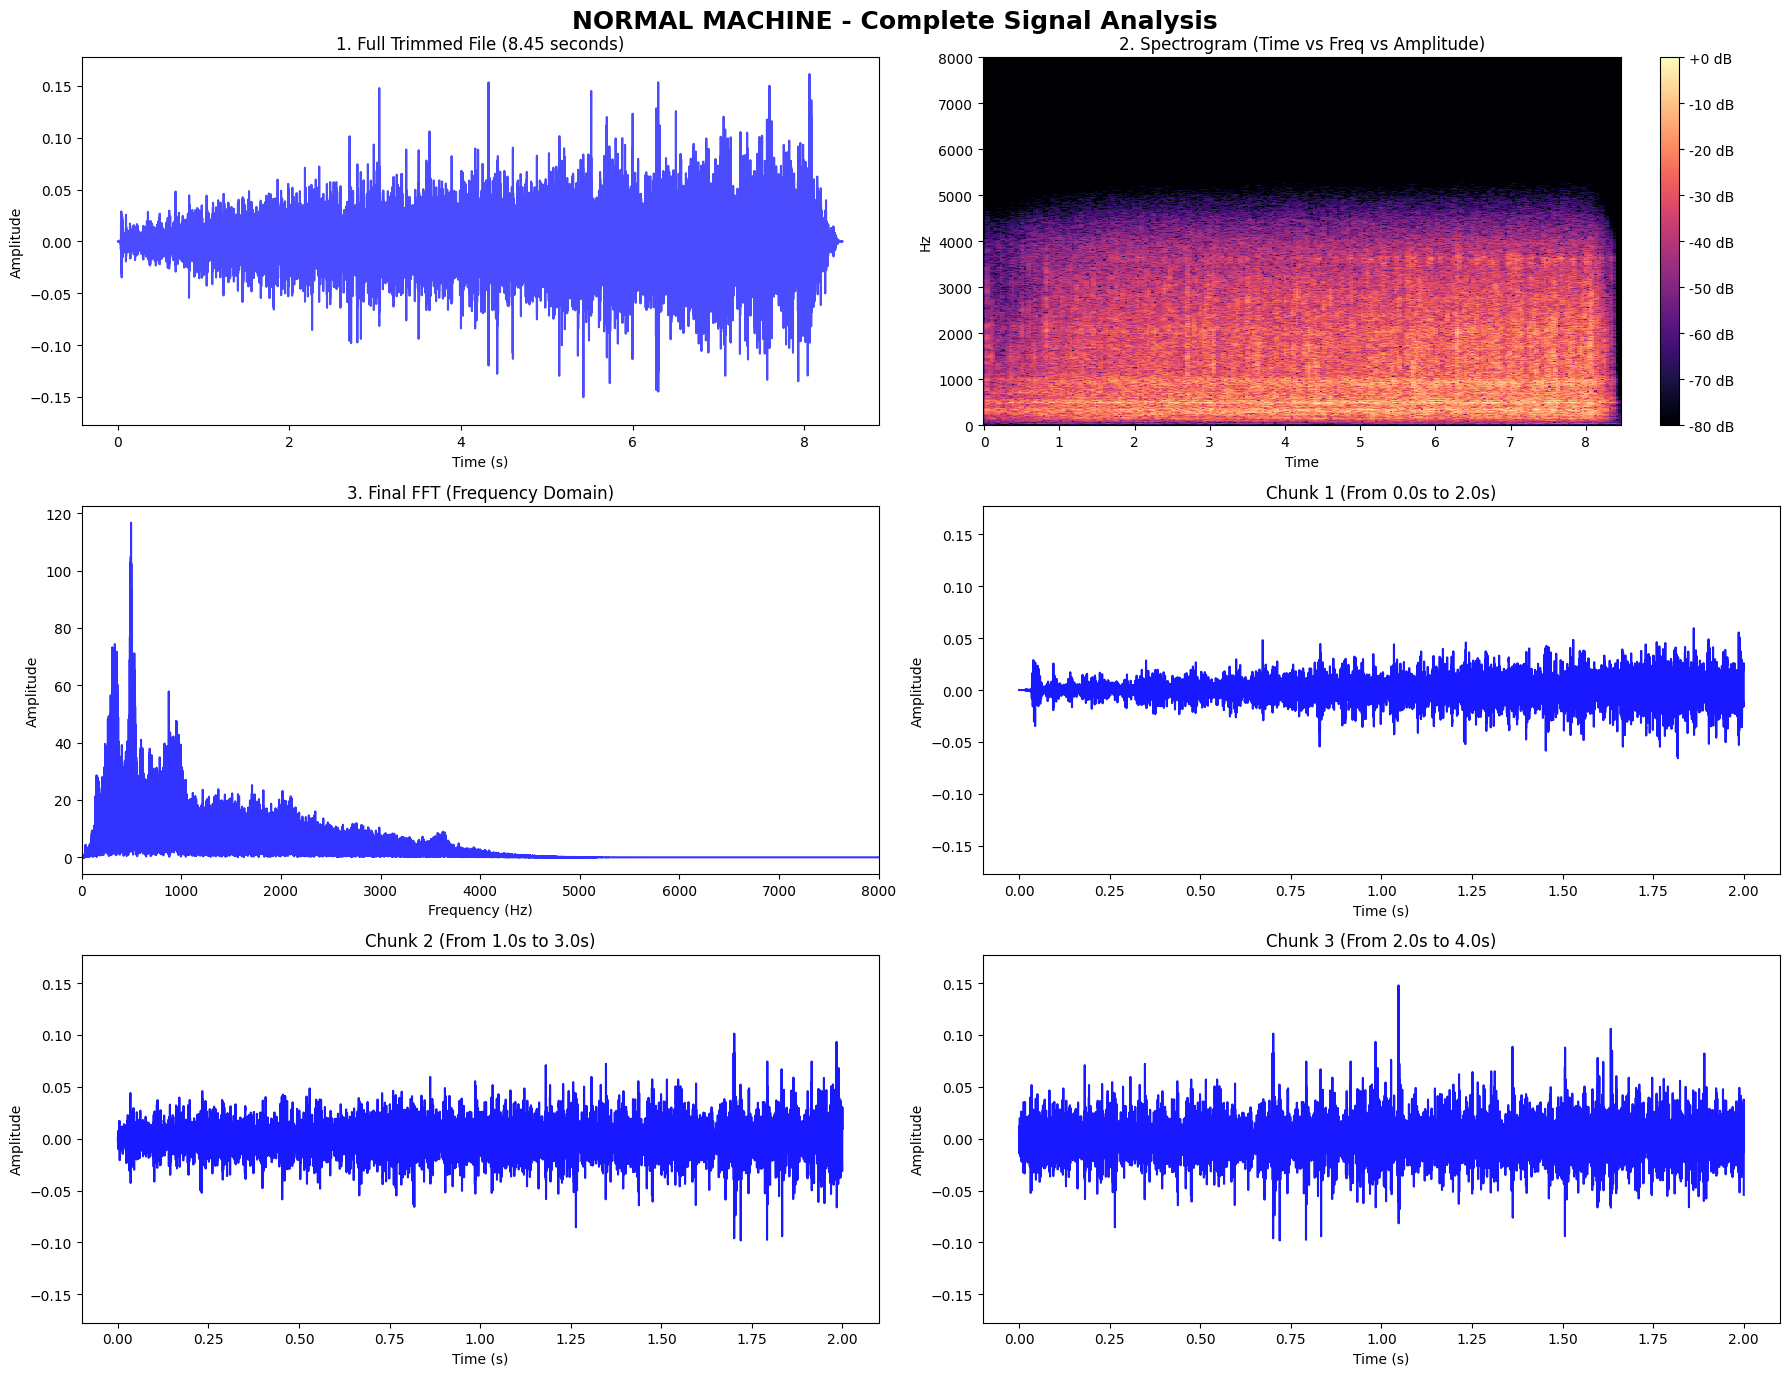

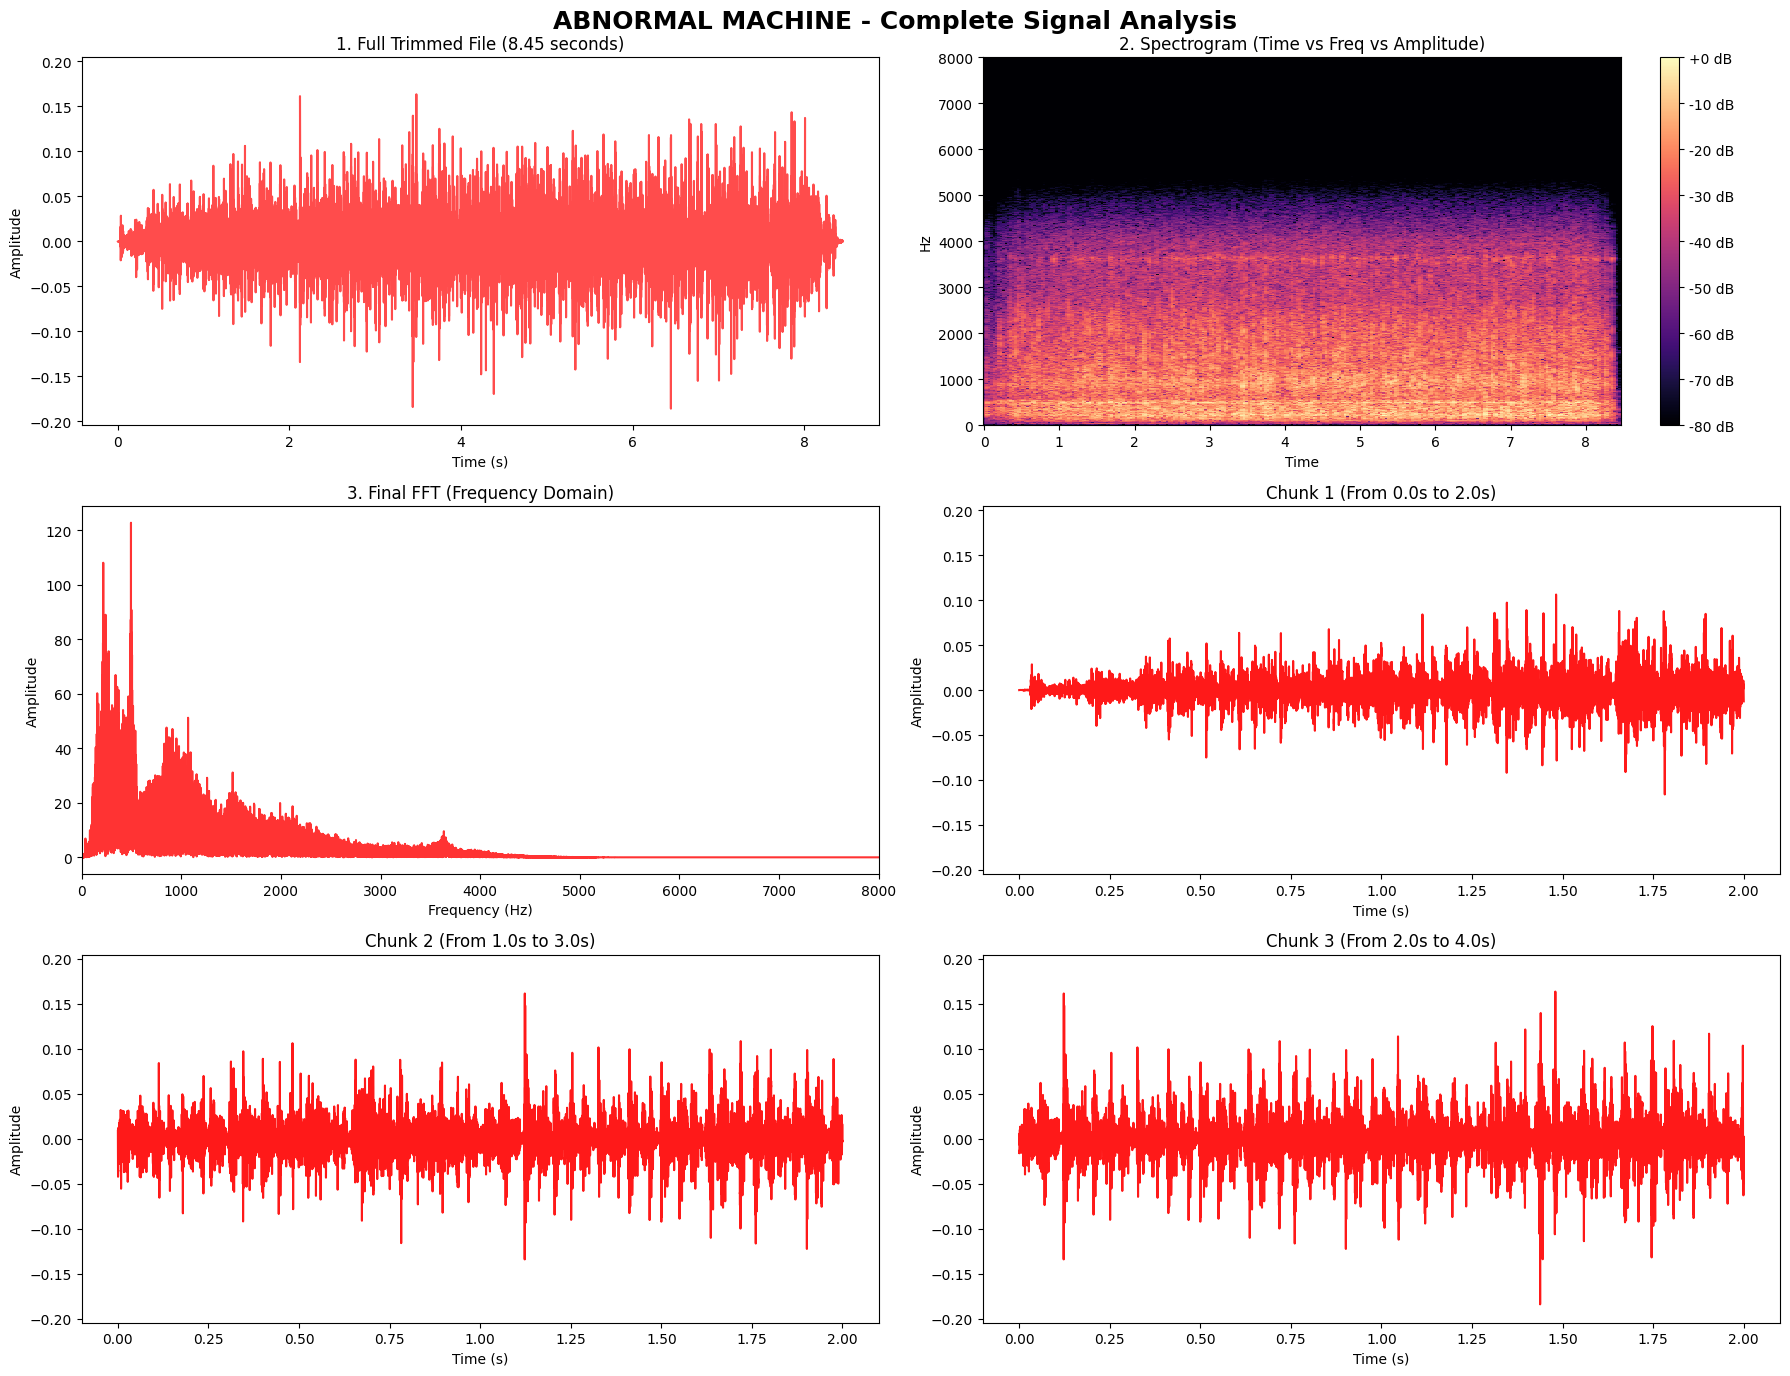

In [11]:
import librosa
import librosa.display
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import random

# --- 1. THE ENGINEERING TOOLS ---
def apply_lowpass_filter(data, cutoff=4000, sr=16000, order=5):
    nyquist = 0.5 * sr
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

def extract_sliding_windows(audio_array, sr, chunk_sec=2.0, overlap_sec=1.0):
    chunk_samples = int(chunk_sec * sr)
    step_samples = int((chunk_sec - overlap_sec) * sr)
    chunks = []
    for start in range(0, len(audio_array) - chunk_samples + 1, step_samples):
        chunks.append(audio_array[start:start + chunk_samples])
    return chunks

# --- 2. SELECT RANDOM SAMPLES ---
normal_dir = "H:/.shortcut-targets-by-id/1pFPnn7lbpxWVfOmrDEyvHxXp0_6GFB90/Students/Machine 1/machine_data/Normal"
abnormal_dir = "H:/.shortcut-targets-by-id/1pFPnn7lbpxWVfOmrDEyvHxXp0_6GFB90/Students/Machine 1/machine_data/Abnormal"

norm_file = os.path.join(normal_dir, random.choice([f for f in os.listdir(normal_dir) if f.endswith('.wav')]))
ab_file = os.path.join(abnormal_dir, random.choice([f for f in os.listdir(abnormal_dir) if f.endswith('.wav')]))

# --- 3. PROCESS THE FILES ---
def process_and_chunk(file_path, sr=16000):
    y, _ = librosa.load(file_path, sr=sr)
    y_filtered = apply_lowpass_filter(y, cutoff=4000, sr=sr)
    y_trimmed, _ = librosa.effects.trim(y_filtered, top_db=26)
    chunks = extract_sliding_windows(y_trimmed, sr=sr, chunk_sec=2.0, overlap_sec=1.0)
    return y_trimmed, chunks

sr = 16000
norm_full, norm_chunks = process_and_chunk(norm_file, sr)
ab_full, ab_chunks = process_and_chunk(ab_file, sr)

# --- 4. THE MASTER DASHBOARD ---
def plot_comprehensive_analysis(full_audio, chunks, title_prefix, color):
    fig = plt.figure(figsize=(18, 14))
    fig.suptitle(f"{title_prefix} - Complete Signal Analysis", fontsize=18, fontweight='bold')
    
    # Calculate the max amplitude to dynamically fix the Y-axis squashing bug!
    max_amp = np.max(np.abs(full_audio)) * 1.1 
    
    # Graph 1: Full Trimmed File (Time Domain)
    ax1 = plt.subplot(3, 2, 1)
    time_full = np.linspace(0, len(full_audio)/sr, len(full_audio))
    ax1.plot(time_full, full_audio, color=color, alpha=0.7)
    ax1.set_title(f"1. Full Trimmed File ({len(full_audio)/sr:.2f} seconds)")
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Amplitude")
    ax1.set_ylim(-max_amp, max_amp)
    
    # Graph 2: The Spectrogram (Time, Freq, Amplitude)
    ax2 = plt.subplot(3, 2, 2)
    # Convert audio to Short-Time Fourier Transform (STFT)
    D = np.abs(librosa.stft(full_audio))
    # Convert to Decibels for visualization
    DB = librosa.amplitude_to_db(D, ref=np.max)
    # Display using Magma colormap (brighter color = higher amplitude)
    img = librosa.display.specshow(DB, sr=sr, x_axis='time', y_axis='hz', ax=ax2, cmap='magma')
    ax2.set_title("2. Spectrogram (Time vs Freq vs Amplitude)")
    ax2.set_ylim(0, 8000) # Cap at 8kHz so we clearly see the 4kHz cutoff
    fig.colorbar(img, ax=ax2, format="%+2.0f dB")
    
    # Graph 3: Final FFT (Frequency Domain)
    ax3 = plt.subplot(3, 2, 3)
    spectrum = np.abs(np.fft.fft(full_audio))
    freqs = np.fft.fftfreq(len(full_audio), 1/sr)
    half_n = len(full_audio) // 2
    ax3.plot(freqs[:half_n], spectrum[:half_n], color=color, alpha=0.8)
    ax3.set_title("3. Final FFT (Frequency Domain)")
    ax3.set_xlabel("Frequency (Hz)")
    ax3.set_ylabel("Amplitude")
    ax3.set_xlim(0, 8000) # Cap at 8kHz
    
    # Graphs 4, 5, 6: The Overlapping Chunks
    for i in range(3):
        # Position them in the bottom row and the empty slot in the middle row
        ax = plt.subplot(3, 2, i+4)
        chunk = chunks[i]
        time_chunk = np.linspace(0, len(chunk)/sr, len(chunk))
        
        ax.plot(time_chunk, chunk, color=color, alpha=0.9)
        
        start_time = i * 1.0
        end_time = start_time + 2.0
        
        ax.set_title(f"Chunk {i+1} (From {start_time}s to {end_time}s)")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Amplitude")
        # Apply the dynamic Y-axis fix here so they match the parent file!
        ax.set_ylim(-max_amp, max_amp) 

    plt.tight_layout()
    plt.show()

# Generate the two dashboards
plot_comprehensive_analysis(norm_full, norm_chunks, "NORMAL MACHINE", "blue")
plot_comprehensive_analysis(ab_full, ab_chunks, "ABNORMAL MACHINE", "red")

CLAUDE'S SUGGESTED ENHANCED PIPELINE

Processing: 1890.wav
Chunks: 34 kept / 1 rejected / 35 total


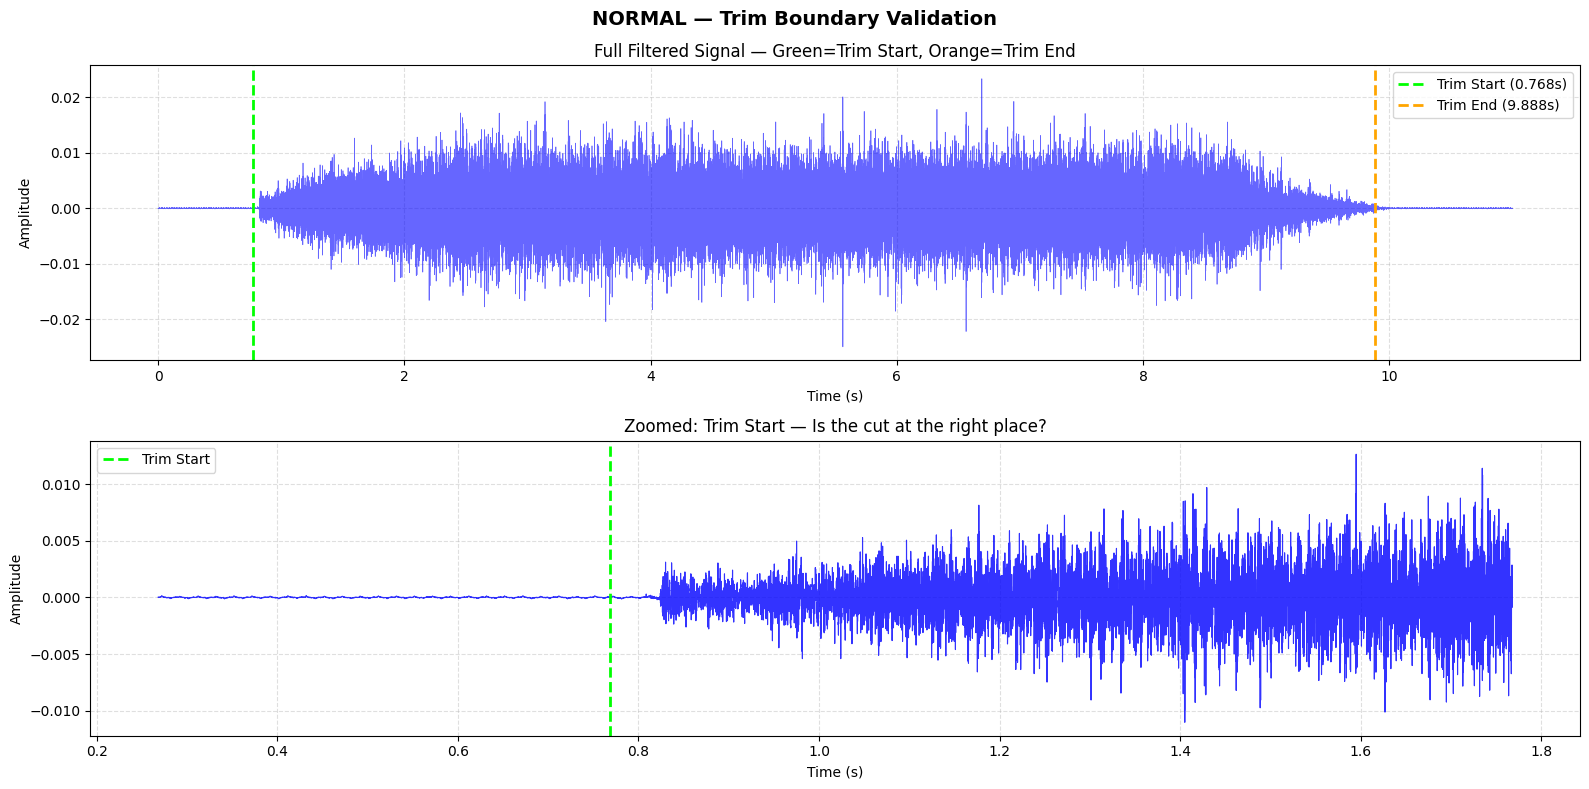

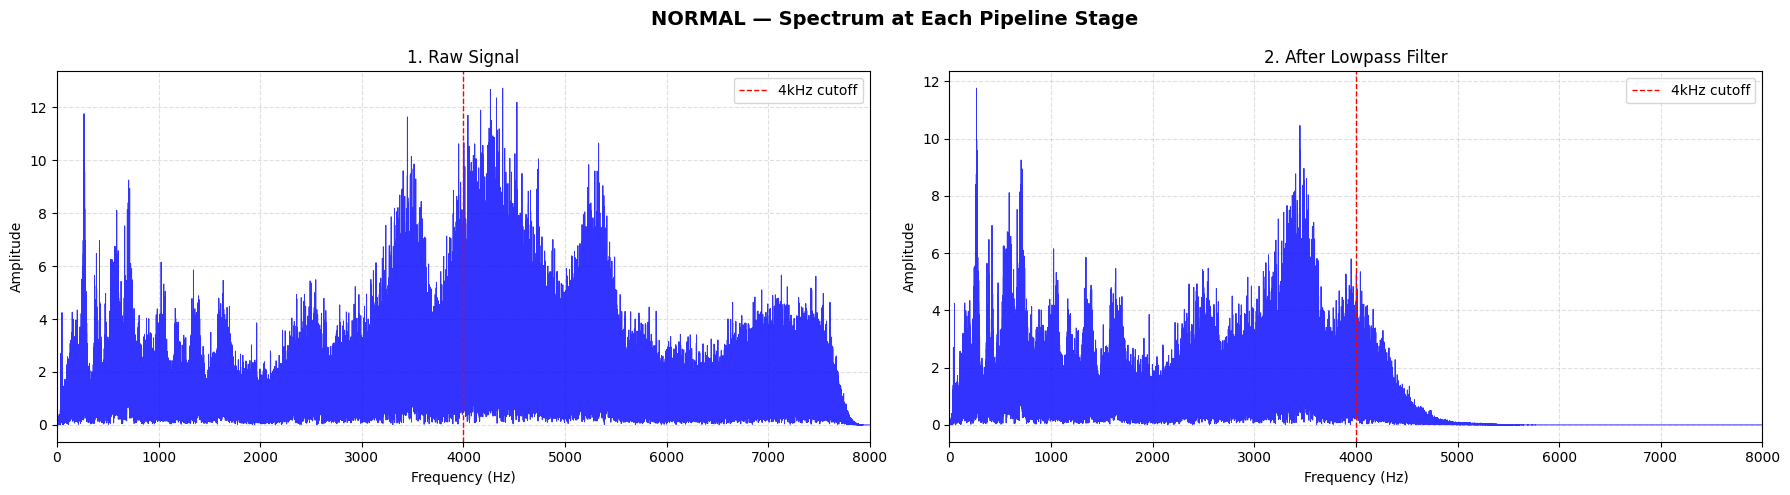

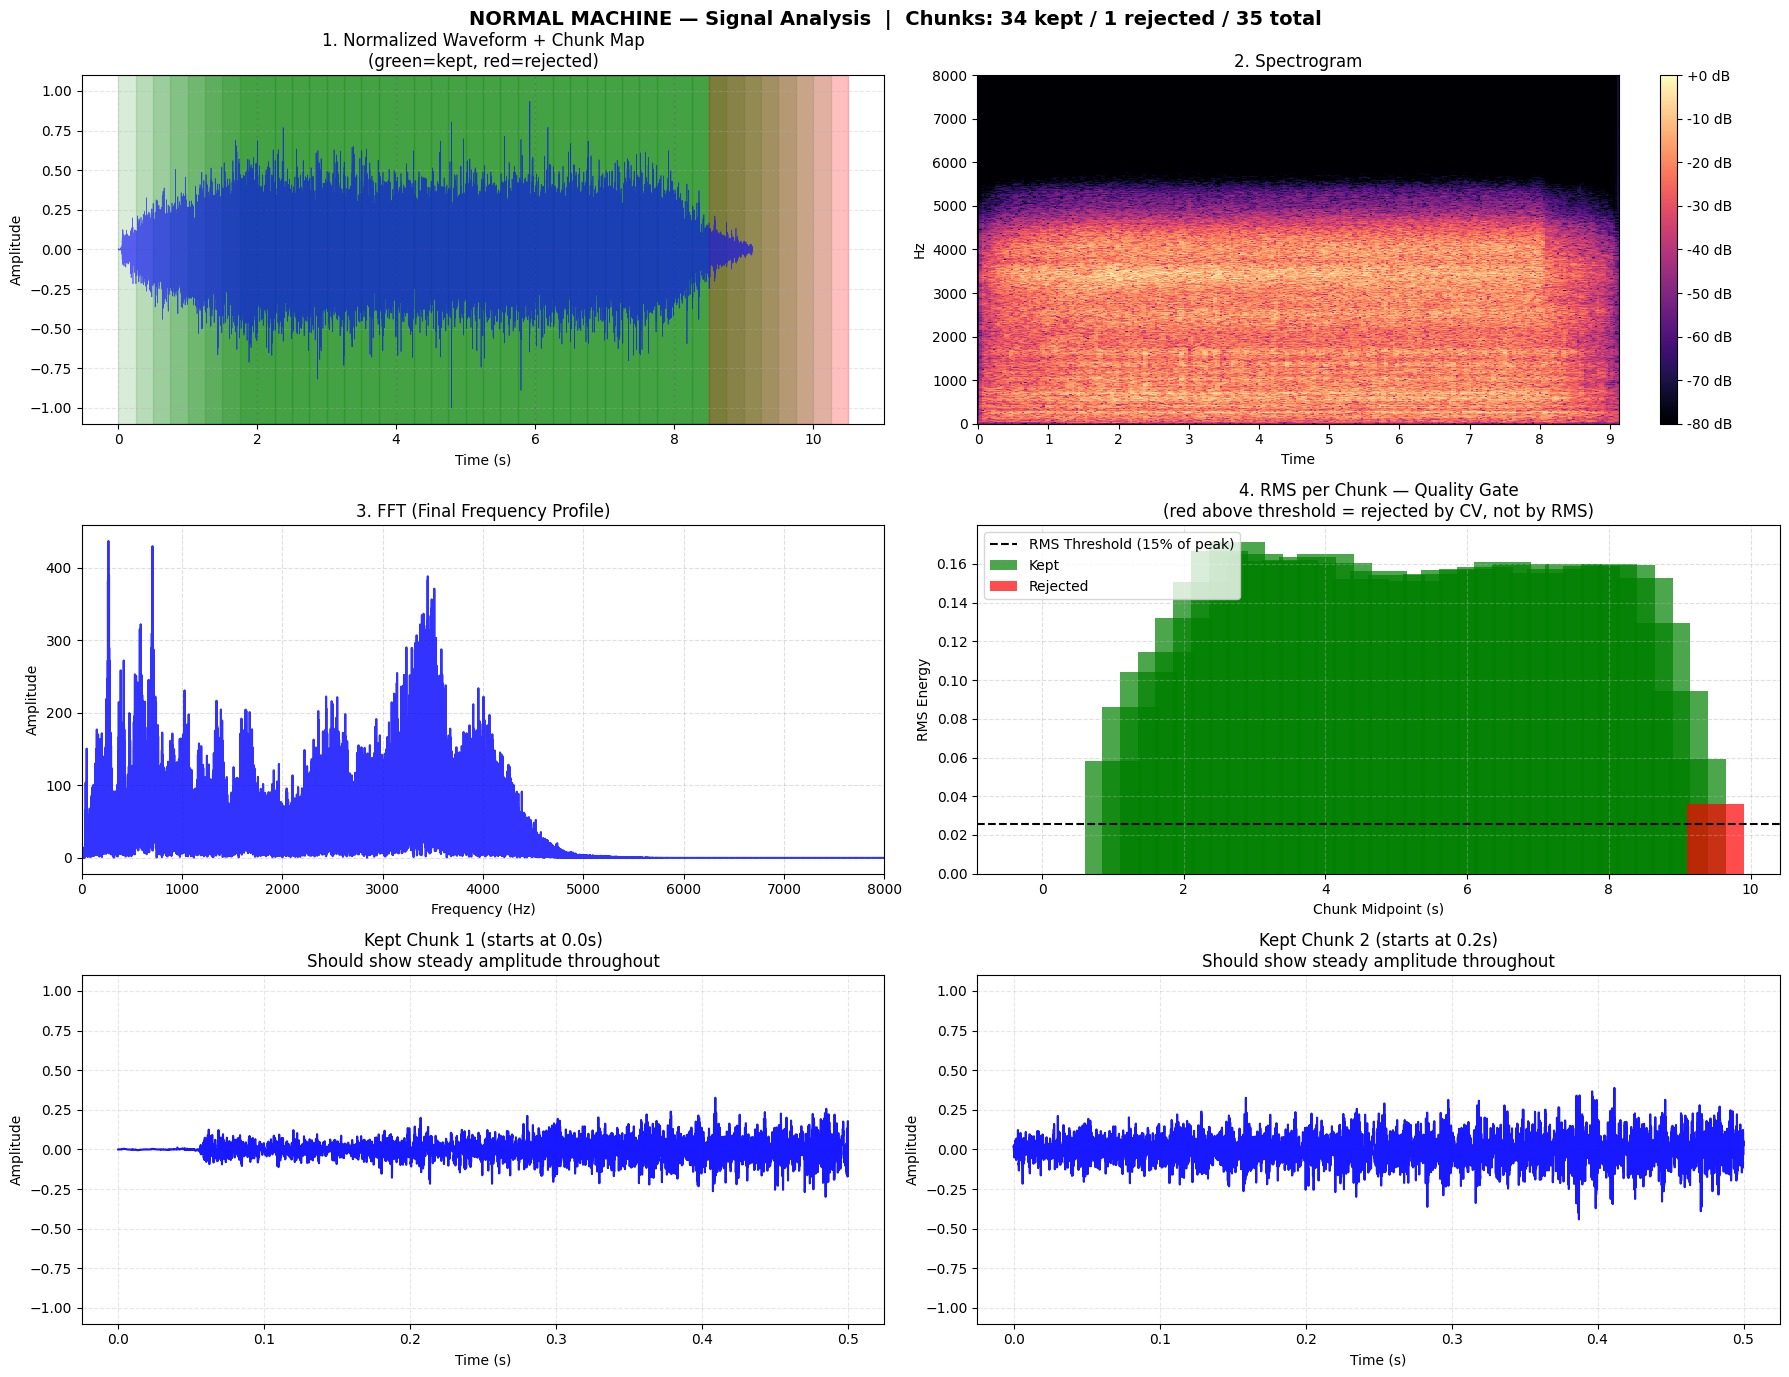

In [26]:
import librosa
import librosa.display
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import random

# ============================================================
# --- 1. ENGINEERING TOOLS ---
# ============================================================

def remove_dc_offset(y):
    """
    Subtracts the mean of the signal from every sample.
    
    A DC offset is a constant bias in the waveform caused by
    microphone/sensor imperfections. Mathematically:
    
        y_clean[n] = y[n] - mean(y)
    
    Without this, the FFT produces a spike at 0Hz that pollutes
    the entire frequency analysis. One line, costs nothing.
    """
    return y - np.mean(y)


'''def apply_preemphasis(y, coeff=0.97):
    """
    Applies a first-order high-shelf filter to flatten the spectrum.
    
    Difference equation:
        y[n] = x[n] - coeff * x[n-1]
    
    This computes the difference between consecutive samples.
    Rapidly changing signal (high frequency) → large difference → survives.
    Slowly changing signal (low frequency)   → small difference → suppressed.
    
    Transfer function: H(z) = 1 - coeff * z^(-1)
    Magnitude response: |H(f)| = sqrt(1 + coeff² - 2*coeff*cos(2πf/sr))
    
    At f=0Hz    → gain = 1 - coeff = 0.03  (low freq nearly killed)
    At f=8000Hz → gain = 1 + coeff = 1.97  (high freq nearly doubled)
    
    Why coeff=0.97:
    The -3dB point lands at ~120Hz, meaning everything above 120Hz
    (all your mechanical grinding frequencies 300Hz-4kHz) gets boosted.
    Sub-120Hz rumble gets suppressed. Standard value for audio DSP.
    
    np.append handles the boundary: first sample has no previous sample,
    so we keep it unchanged.
    """
    return np.append(y[0], y[1:] - coeff * y[:-1])'''


def apply_lowpass_filter(y, cutoff=4000, sr=16000, order=5):
    """
    5th-order Butterworth low-pass filter, zero-phase (filtfilt).
    
    Kills everything above 4kHz — validated by FFT analysis across
    150 files showing no meaningful signal above this cutoff.
    
    filtfilt applies the filter forward then backward, which:
    - Doubles the effective filter order (5th order → 10th order roll-off)
    - Eliminates phase distortion (zero-phase)
    
    Roll-off: ~30dB/octave (5th order Butterworth), meaning frequencies
    just above 4kHz are strongly attenuated without ringing artifacts.
    
    Order of operations matters: pre-emphasis boosted high frequencies,
    then this filter cuts them back above 4kHz. The net effect is a
    flattened spectrum from 120Hz to 4kHz, with clean cutoff above.
    """
    nyquist = 0.5 * sr
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, y)


def apply_trim(y, top_db=26, frame_length=512, hop_length=128):
    """
    Removes leading and trailing silence using librosa's energy-based trim.
    
    top_db=26 means: cut any region whose energy is more than 26dB
    below the peak energy of the file.
    
    26dB in linear scale:
        threshold = peak_amplitude / 10^(26/20) ≈ peak / 20 ≈ 5% of peak
    
    Why trim AFTER filtering and pre-emphasis:
    If you trimmed the raw signal, the silence threshold would be measured
    against unfiltered noise, giving inconsistent cut points across files.
    Trimming the clean signal gives consistent, reliable boundaries.
    
    Returns both the trimmed audio AND the trim indices so we can
    visualize exactly where the cuts happened.
    """
    y_trimmed, trim_indices = librosa.effects.trim(y, top_db=top_db)
    return y_trimmed, trim_indices


def apply_peak_normalization(y):
    """
    Scales the entire trimmed signal so its peak amplitude = 1.0.
    
        y_norm[n] = y[n] / max(|y[n]|)
    
    Why per-file (not per-chunk):
    If you normalize per chunk, you destroy the relative energy differences
    between chunks within the same file — a quiet ramp-up chunk would be
    scaled up to match a loud steady-state chunk, making them look identical.
    
    Normalizing per file preserves the relative loudness between chunks
    while ensuring all files sit on the same amplitude scale regardless of
    microphone distance or recording gain.
    
    The 1e-9 prevents division by zero on silent files.
    """
    peak = np.max(np.abs(y))
    return y / (peak + 1e-9)


def extract_sliding_windows(y, sr, chunk_sec=0.5, overlap_sec=0.25):
    """
    Segments the trimmed, normalized signal into overlapping fixed-length chunks.
    
    Parameters:
        chunk_sec=0.5  → each chunk is exactly 0.5 seconds = 8,000 samples at sr=16000
        overlap_sec=0.25 → chunks start every 0.25 seconds (50% overlap)
    
    Step size = chunk_sec - overlap_sec = 1.0 second = 16,000 samples
    
    For a 9.5s file:
        Chunk 1: 0.0s → 2.0s
        Chunk 2: 1.0s → 3.0s
        Chunk 3: 2.0s → 4.0s
        ...
        Chunk 8: 7.0s → 9.0s   ← last full chunk that fits
    
    The final incomplete chunk is dropped (range condition ensures this).
    start positions are tracked so we know where each chunk lives in
    the parent file — needed for the quality gate visualization and
    for the chunk naming convention later.
    """
    chunk_samples = int(chunk_sec * sr)
    step_samples  = int((chunk_sec - overlap_sec) * sr)
    chunks, starts = [], []
    for start in range(0, len(y) - chunk_samples + 1, step_samples):
        chunks.append(y[start:start + chunk_samples])
        starts.append(start)
    return chunks, starts


# ============================================================
# --- 2. CV QUALITY GATE ---
# ============================================================

def compute_rms(chunk):
    """
    Root Mean Square — single number representing average loudness.
    
        RMS = sqrt( mean( x[n]² ) )
    
    Squaring makes all values positive and penalizes large deviations.
    Square root brings it back to the same units as the original signal.
    """
    return np.sqrt(np.mean(chunk ** 2))


def is_uneven_chunk(chunk, n_windows=8, cv_threshold=1.2):
    """
    Coefficient of Variation (CV) based steady-state detector.
    
    Step 1: Split chunk into n_windows equal windows (8 × 250ms for 2s chunk)
    Step 2: Compute RMS of each window → [RMS_1, RMS_2, ..., RMS_8]
    Step 3: CV = std(RMS values) / mean(RMS values)
    
    CV measures RELATIVE variation — how uneven the energy is as a
    proportion of the average energy level. This makes it scale-independent:
    a loud ramp and a quiet ramp both get high CV,
    a loud steady chunk and a quiet steady chunk both get low CV.
    
    Why not just use std(RMS)?
    std is scale-dependent. A loud ramp has large std simply because
    it's loud. CV divides out the scale, leaving only the unevenness.
    
    cv_threshold=0.8 means: reject if std of window RMS values exceeds
    80% of their mean. This catches:
        - Ramp-up   (quiet start, loud end)
        - Ramp-down (loud start, quiet end)
        - Dropouts  (sudden silence mid-chunk)
        - Impacts   (sudden spike mid-chunk)
        - Any other energy inconsistency regardless of shape or position
    
    It is a general steady-state detector, not a ramp-specific detector.
    """
    window_size = len(chunk) // n_windows
    rms_values  = np.array([
        compute_rms(chunk[i * window_size:(i + 1) * window_size])
        for i in range(n_windows)
    ])
    
    mean_rms = rms_values.mean()
    if mean_rms == 0:
        return True  # fully silent chunk → always reject
    
    cv = rms_values.std() / mean_rms
    return cv > cv_threshold


def filter_chunks_by_quality(chunks, starts,
                              rms_threshold_ratio=0.30,
                              cv_threshold=1.2):
    """
    Two-stage quality gate applied to every chunk:
    
    Gate 1 — Global RMS threshold:
        Reject if chunk RMS < 15% of the loudest chunk's RMS.
        Catches fully silent or near-silent chunks that somehow
        survived trimming.
    
    Gate 2 — CV steady-state check:
        Reject if the chunk's energy is not consistent throughout.
        Catches ramps, dropouts, impacts, and any transient events.
    
    A chunk must PASS BOTH gates to be kept.
    Chunks that fail either gate are tracked separately so they can
    be visualized — you need to see what's being rejected and why.
    """
    rms_values = np.array([compute_rms(c) for c in chunks])
    peak_rms   = rms_values.max()
    threshold  = peak_rms * rms_threshold_ratio
    
    kept_chunks,     kept_starts,     kept_rms     = [], [], []
    rejected_chunks, rejected_starts, rejected_rms = [], [], []
    
    for chunk, start, rms in zip(chunks, starts, rms_values):
        too_quiet  = rms < threshold
        too_uneven = is_uneven_chunk(chunk, cv_threshold=cv_threshold)
        
        if not too_quiet and not too_uneven:
            kept_chunks.append(chunk)
            kept_starts.append(start)
            kept_rms.append(rms)
        else:
            rejected_chunks.append(chunk)
            rejected_starts.append(start)
            rejected_rms.append(rms)
    
    return (kept_chunks,     kept_starts,     kept_rms,
            rejected_chunks, rejected_starts, rejected_rms)


# ============================================================
# --- 3. MASTER PROCESS FUNCTION ---
# ============================================================

def process_and_chunk(file_path, sr=16000,
                      rms_threshold_ratio=0.30,
                      cv_threshold=1.2):
    """
    Full pipeline for one audio file. Returns a dict containing
    every intermediate stage so any step can be inspected or plotted.
    
    Pipeline order:
        Load
        → DC Offset Removal     (remove microphone bias)
        → Pre-emphasis          (flatten spectrum)
        → Lowpass Filter @4kHz  (remove high-freq hiss)
        → Trim                  (cut silence on clean signal)
        → Peak Normalize        (equalize volume across files)
        → Sliding Window        (produce fixed-length chunks)
        → CV Quality Gate       (reject unsteady chunks)
    """
    # Step 0: Load
    y_raw, _ = librosa.load(file_path, sr=sr)
    
    # Step 1: DC offset removal
    y_dc = remove_dc_offset(y_raw)
    
    # Step 2: Pre-emphasis
    #y_pre = apply_preemphasis(y_dc, coeff=0.97)
    
    # Step 3: Lowpass filter
    y_filtered = apply_lowpass_filter(y_dc, cutoff=4000, sr=sr)
    
    # Step 4: Trim
    y_trimmed, trim_indices = apply_trim(y_filtered, top_db=26, frame_length=512, hop_length=128)
    trim_start_sec = trim_indices[0] / sr
    trim_end_sec   = trim_indices[1] / sr
    
    # Step 5: Peak normalize — on the full trimmed file, not per chunk
    y_normalized = apply_peak_normalization(y_trimmed)
    
    # Step 6: Sliding window
    chunks, starts = extract_sliding_windows(
        y_normalized, sr, chunk_sec=0.5, overlap_sec=0.25
    )
    
    # Step 7: CV quality gate
    (kept_chunks,     kept_starts,     kept_rms,
     rejected_chunks, rejected_starts, rejected_rms) = filter_chunks_by_quality(
        chunks, starts,
        rms_threshold_ratio=rms_threshold_ratio,
        cv_threshold=cv_threshold
    )
    
    return {
        # Every pipeline stage preserved for inspection
        "raw":              y_raw,
        "dc_removed":       y_dc,
       # "preemphasized":    y_pre,
        "filtered":         y_filtered,
        "trimmed":          y_trimmed,
        "normalized":       y_normalized,
        "trim_start_sec":   trim_start_sec,
        "trim_end_sec":     trim_end_sec,
        # Chunk data
        "all_chunks":       chunks,
        "all_starts":       starts,
        "kept_chunks":      kept_chunks,
        "kept_starts":      kept_starts,
        "kept_rms":         kept_rms,
        "rejected_chunks":  rejected_chunks,
        "rejected_starts":  rejected_starts,
        "rejected_rms":     rejected_rms,
    }


# ============================================================
# --- 4. TRIM BOUNDARY VALIDATION PLOT ---
# ============================================================

def plot_trim_validation(result, sr, title_prefix, color):
    """
    Validates that top_db=26 is cutting at the right place.
    
    Top plot:    full filtered signal with trim boundaries marked
    Bottom plot: zoomed into the trim start region for precise inspection
    
    What to look for:
    - Everything LEFT of green line should be flat/near-zero
    - Signal should begin immediately RIGHT of green line
    - If signal starts before green line → top_db too aggressive (raise it)
    - If flat region exists after green line → top_db too loose (lower it)
    """
    fig, axes = plt.subplots(2, 1, figsize=(16, 8))
    fig.suptitle(f"{title_prefix} — Trim Boundary Validation",
                 fontsize=14, fontweight='bold')
    
    y_filt    = result["filtered"]
    time_full = np.linspace(0, len(y_filt) / sr, len(y_filt))
    
    # Top: full signal
    ax = axes[0]
    ax.plot(time_full, y_filt, color=color, alpha=0.6, linewidth=0.5)
    ax.axvline(result["trim_start_sec"], color='lime',   linewidth=2,
               linestyle='--', label=f'Trim Start ({result["trim_start_sec"]:.3f}s)')
    ax.axvline(result["trim_end_sec"],   color='orange', linewidth=2,
               linestyle='--', label=f'Trim End ({result["trim_end_sec"]:.3f}s)')
    ax.set_title("Full Filtered Signal — Green=Trim Start, Orange=Trim End")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)
    
    # Bottom: zoomed into trim start
    ax2        = axes[1]
    zoom_start = max(0, result["trim_start_sec"] - 0.5)
    zoom_end   = zoom_start + 1.5
    zoom_s     = int(zoom_start * sr)
    zoom_e     = int(zoom_end   * sr)
    y_zoom     = y_filt[zoom_s:zoom_e]
    t_zoom     = np.linspace(zoom_start, zoom_end, len(y_zoom))
    
    ax2.plot(t_zoom, y_zoom, color=color, alpha=0.8, linewidth=0.8)
    ax2.axvline(result["trim_start_sec"], color='lime', linewidth=2,
                linestyle='--', label='Trim Start')
    ax2.set_title("Zoomed: Trim Start — Is the cut at the right place?")
    ax2.set_xlabel("Time (s)")
    ax2.set_ylabel("Amplitude")
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.show()


# ============================================================
# --- 5. SPECTRUM COMPARISON PLOT ---
# ============================================================

def plot_spectrum_stages(result, sr, title_prefix, color):
    """
    Plots FFT at three pipeline stages side by side:
        1. Raw signal         → shows original spectrum with DC and hiss
        2. After pre-emphasis → shows flattened spectrum before filtering
        3. After filtering    → shows final clean spectrum fed into trim
    
    This is how you visually confirm that pre-emphasis and the
    lowpass filter are doing what the math says they should do.
    
    What to look for:
    - Stage 1→2: low frequencies should drop, high frequencies should rise
    - Stage 2→3: clean cutoff at 4kHz, nothing above it
    """
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    fig.suptitle(f"{title_prefix} — Spectrum at Each Pipeline Stage",
                 fontsize=14, fontweight='bold')
    
    stages = [
        (result["raw"],       "1. Raw Signal"),
        #(result["preemphasized"], "2. After Pre-emphasis"),
        (result["filtered"],  "2. After Lowpass Filter"),
    ]
    
    for ax, (signal, stage_title) in zip(axes, stages):
        n       = len(signal)
        spectrum = np.abs(np.fft.fft(signal))[:n // 2]
        freqs    = np.fft.fftfreq(n, 1 / sr)[:n // 2]
        ax.plot(freqs, spectrum, color=color, alpha=0.8, linewidth=0.7)
        ax.set_title(stage_title)
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Amplitude")
        ax.set_xlim(0, 8000)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.axvline(4000, color='red', linestyle='--',
                   linewidth=1, label='4kHz cutoff')
        ax.legend()
    
    plt.tight_layout()
    plt.show()


# ============================================================
# --- 6. MAIN DASHBOARD ---
# ============================================================

def plot_comprehensive_analysis(result, sr, title_prefix, color):
    """
    Six-panel dashboard showing the full pipeline output for one file.
    
    Panel 1: Trimmed normalized waveform with chunk map
             Green spans = kept chunks, Red spans = rejected chunks
             Lets you see spatially which chunks were rejected and where
    
    Panel 2: Spectrogram of the normalized signal
             Time vs Frequency vs Amplitude in dB
             Should show hard black above 5kHz (filter working)
    
    Panel 3: FFT of the normalized signal
             Final frequency profile after all processing
    
    Panel 4: RMS bar chart per chunk
             Each bar = one chunk, colored green (kept) or red (rejected)
             Dashed line = the 15% RMS threshold
             CV rejections show up here as red bars ABOVE the threshold
             (rejected not because too quiet but because too uneven)
    
    Panel 5: First kept chunk waveform
    Panel 6: Second kept chunk waveform
             These should look like steady-state grinding — no ramps,
             no dropouts, consistent amplitude throughout
    """
    kept  = result["kept_chunks"]
    full  = result["normalized"]
    n_kept  = len(kept)
    n_rej   = len(result["rejected_chunks"])
    n_total = n_kept + n_rej
    
    fig = plt.figure(figsize=(18, 14))
    fig.suptitle(
        f"{title_prefix} — Signal Analysis  |  "
        f"Chunks: {n_kept} kept / {n_rej} rejected / {n_total} total",
        fontsize=14, fontweight='bold'
    )
    
    max_amp       = np.max(np.abs(full)) * 1.1
    chunk_samples = int(2.0 * sr)
    
    # --- Panel 1: Waveform + chunk map ---
    ax1       = plt.subplot(3, 2, 1)
    time_full = np.linspace(0, len(full) / sr, len(full))
    ax1.plot(time_full, full, color=color, alpha=0.6, linewidth=0.5)
    
    for start in result["kept_starts"]:
        ax1.axvspan(start / sr, (start + chunk_samples) / sr,
                    alpha=0.15, color='green')
    for start in result["rejected_starts"]:
        ax1.axvspan(start / sr, (start + chunk_samples) / sr,
                    alpha=0.25, color='red')
    
    ax1.set_title("1. Normalized Waveform + Chunk Map\n(green=kept, red=rejected)")
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Amplitude")
    ax1.set_ylim(-max_amp, max_amp)
    ax1.grid(True, linestyle='--', alpha=0.3)
    
    # --- Panel 2: Spectrogram ---
    ax2  = plt.subplot(3, 2, 2)
    D    = np.abs(librosa.stft(full))
    DB   = librosa.amplitude_to_db(D, ref=np.max)
    img  = librosa.display.specshow(DB, sr=sr, x_axis='time',
                                    y_axis='hz', ax=ax2, cmap='magma')
    ax2.set_title("2. Spectrogram")
    ax2.set_ylim(0, 8000)
    fig.colorbar(img, ax=ax2, format="%+2.0f dB")
    
    # --- Panel 3: FFT ---
    ax3      = plt.subplot(3, 2, 3)
    spectrum = np.abs(np.fft.fft(full))
    freqs    = np.fft.fftfreq(len(full), 1 / sr)
    half_n   = len(full) // 2
    ax3.plot(freqs[:half_n], spectrum[:half_n], color=color, alpha=0.8)
    ax3.set_title("3. FFT (Final Frequency Profile)")
    ax3.set_xlabel("Frequency (Hz)")
    ax3.set_ylabel("Amplitude")
    ax3.set_xlim(0, 8000)
    ax3.grid(True, linestyle='--', alpha=0.4)
    
    # --- Panel 4: RMS bar chart with CV rejection visibility ---
    ax4        = plt.subplot(3, 2, 4)
    all_starts = result["all_starts"]
    all_rms    = [compute_rms(c) for c in result["all_chunks"]]
    times_mid  = [(s + int(sr)) / sr for s in all_starts]
    kept_set   = set(result["kept_starts"])
    
    for t, r, s in zip(times_mid, all_rms, all_starts):
        bar_color = 'green' if s in kept_set else 'red'
        ax4.bar(t, r, width=0.8, color=bar_color, alpha=0.7)
    
    # RMS threshold line
    peak_rms  = max(all_rms)
    threshold = peak_rms * 0.15
    ax4.axhline(threshold, color='black', linestyle='--',
                linewidth=1.5, label='RMS Threshold (15% of peak)')
    
    # Dummy bars for legend
    ax4.bar(0, 0, color='green', alpha=0.7, label='Kept')
    ax4.bar(0, 0, color='red',   alpha=0.7, label='Rejected')
    ax4.set_title("4. RMS per Chunk — Quality Gate\n"
                  "(red above threshold = rejected by CV, not by RMS)")
    ax4.set_xlabel("Chunk Midpoint (s)")
    ax4.set_ylabel("RMS Energy")
    ax4.legend()
    ax4.grid(True, linestyle='--', alpha=0.4)
    
    # --- Panels 5 & 6: First two kept chunks ---
    for i in range(2):
        ax = plt.subplot(3, 2, i + 5)
        if i < len(kept):
            chunk     = kept[i]
            t         = np.linspace(0, len(chunk) / sr, len(chunk))
            start_sec = result["kept_starts"][i] / sr
            ax.plot(t, chunk, color=color, alpha=0.9)
            ax.set_title(f"Kept Chunk {i+1} (starts at {start_sec:.1f}s)\n"
                         f"Should show steady amplitude throughout")
        else:
            ax.set_title(f"Kept Chunk {i+1} — not enough chunks")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Amplitude")
        ax.set_ylim(-max_amp, max_amp)
        ax.grid(True, linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# ============================================================
# --- 7. RUN ON ONE FILE ---
# ============================================================

normal_dir = "H:/.shortcut-targets-by-id/1pFPnn7lbpxWVfOmrDEyvHxXp0_6GFB90/Students/Machine 1/machine_data/Normal"

sr = 16000
random.seed(20)

# Pick one random normal file
norm_file = os.path.join(normal_dir, random.choice(
    [f for f in os.listdir(normal_dir) if f.endswith('.wav')]
))

print(f"Processing: {os.path.basename(norm_file)}")

result = process_and_chunk(norm_file, sr=sr,
                           rms_threshold_ratio=0.30,
                           cv_threshold=1.2)

print(f"Chunks: {len(result['kept_chunks'])} kept / "
      f"{len(result['rejected_chunks'])} rejected / "
      f"{len(result['all_chunks'])} total")

# Plot 1: Trim validation
plot_trim_validation(result, sr, "NORMAL", "blue")

# Plot 2: Spectrum at each pipeline stage
# This confirms pre-emphasis and lowpass are working as expected
plot_spectrum_stages(result, sr, "NORMAL", "blue")

# Plot 3: Full dashboard
plot_comprehensive_analysis(result, sr, "NORMAL MACHINE", "blue")

NOW LET'S SEE THE SAME THINGS FOR MACHINE 2


Analyzing 100 files in Normal...
Analyzing 100 files in Abnormal...


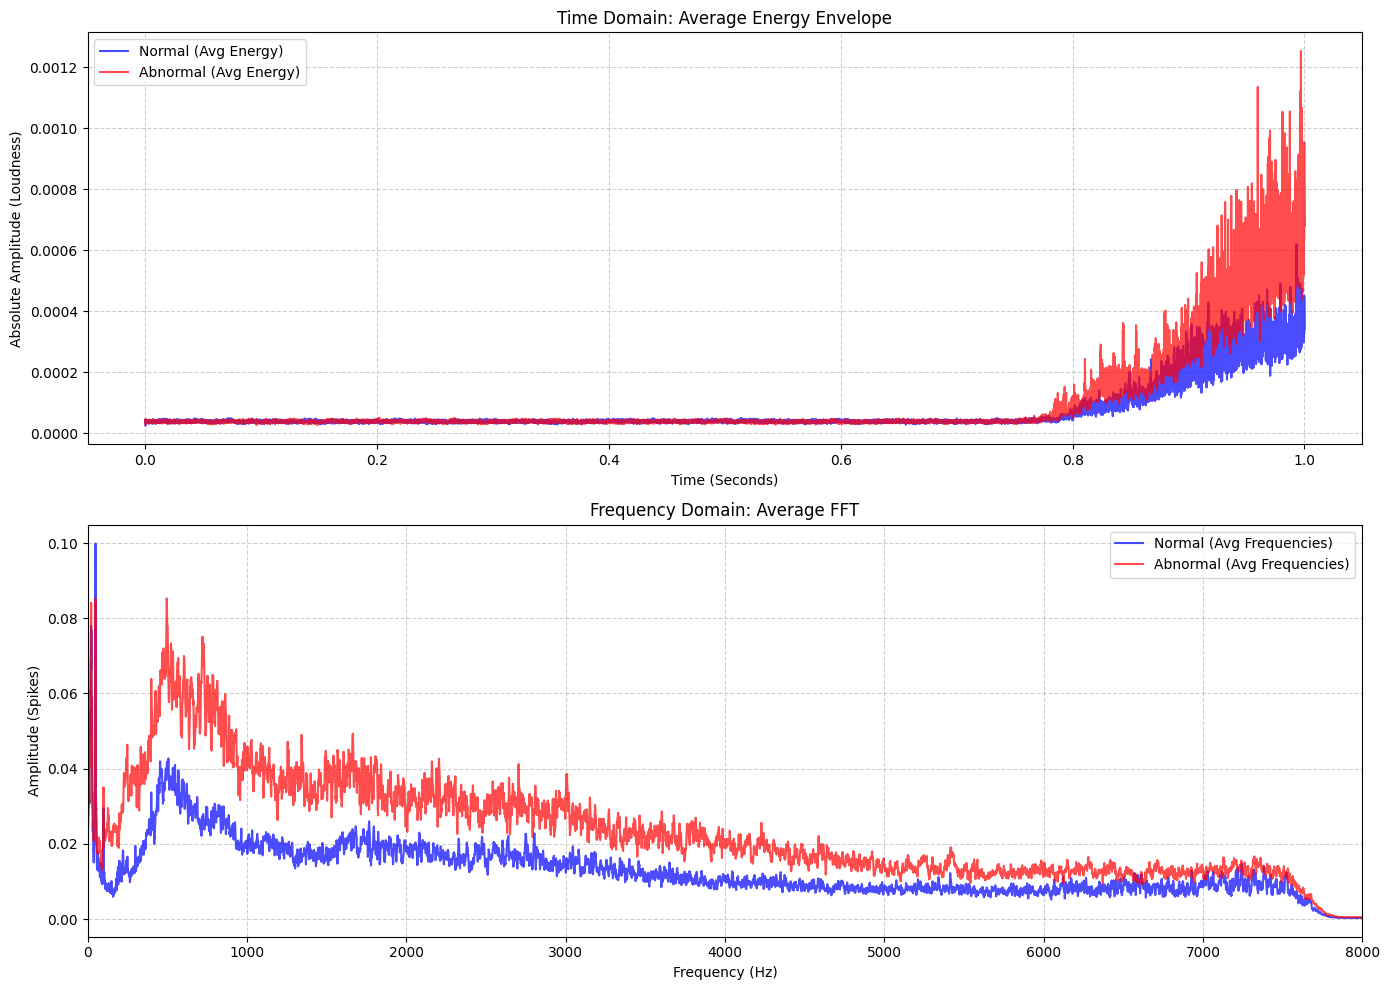

In [ ]:
import librosa
import numpy as np
import os
import matplotlib.pyplot as plt

def compute_average_profiles(folder_path, num_files=150, target_sr=16000):
    """Calculates both the average frequency and average time profiles."""
    audio_files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
    
    np.random.shuffle(audio_files)
    audio_files = audio_files[:num_files]
    
    all_fft_amps = []
    all_time_amps = []
    
    print(f"Analyzing {len(audio_files)} files in {os.path.basename(folder_path)}...")
    
    for filename in audio_files:
        file_path = os.path.join(folder_path, filename)
        
        y, sr = librosa.load(file_path, sr=target_sr, duration=1.0)
        if len(y) < target_sr:
            y = np.pad(y, (0, target_sr - len(y)))
            
        # --- 1. FFT (Frequency) Processing ---
        spectrum = np.abs(np.fft.fft(y))
        half_point = len(spectrum) // 2
        pos_amps = spectrum[:half_point]
        all_fft_amps.append(pos_amps)
        
        # --- 2. Time (Amplitude) Processing ---
        # Crucial: Take the absolute value so waves don't cancel each other out!
        all_time_amps.append(np.abs(y))
        
    # Calculate the averages
    avg_fft = np.mean(all_fft_amps, axis=0)
    avg_time = np.mean(all_time_amps, axis=0)
    
    # Calculate X-axis labels
    freqs = np.fft.fftfreq(target_sr, 1/target_sr)[:half_point]
    times = np.linspace(0, 1.0, target_sr) # Creates a time axis from 0s to 1s
    
    return freqs, avg_fft, times, avg_time

# --- RUN THE ENGINE ---

normal_dir = "H:/.shortcut-targets-by-id/1pFPnn7lbpxWVfOmrDEyvHxXp0_6GFB90/Students/Machine 2/machine_data/Normal"
abnormal_dir = "H:/.shortcut-targets-by-id/1pFPnn7lbpxWVfOmrDEyvHxXp0_6GFB90/Students/Machine 2/machine_data/Abnormal"

# Get data for both
norm_freqs, norm_fft_avg, norm_times, norm_time_avg = compute_average_profiles(normal_dir, num_files=100)
ab_freqs, ab_fft_avg, ab_times, ab_time_avg = compute_average_profiles(abnormal_dir, num_files=100)

# --- PLOT BOTH GRAPHS ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# 1. The Time Graph (Amplitude Envelope)
ax1.plot(norm_times, norm_time_avg, label='Normal (Avg Energy)', color='blue', alpha=0.7)
ax1.plot(ab_times, ab_time_avg, label='Abnormal (Avg Energy)', color='red', alpha=0.7)
ax1.set_title('Time Domain: Average Energy Envelope')
ax1.set_xlabel('Time (Seconds)')
ax1.set_ylabel('Absolute Amplitude (Loudness)')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# 2. The Frequency Graph (FFT)
ax2.plot(norm_freqs, norm_fft_avg, label='Normal (Avg Frequencies)', color='blue', alpha=0.7)
ax2.plot(ab_freqs, ab_fft_avg, label='Abnormal (Avg Frequencies)', color='red', alpha=0.7)
ax2.set_title('Frequency Domain: Average FFT')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Amplitude (Spikes)')
ax2.set_xlim(0, 8000) # Nyquist limit for 16kHz
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

LET'S SEE A SAMPLE OF MACHINE 2 AFTER PREPROCESSING

Processing: 486.wav
Chunks: 9 kept / 25 rejected / 34 total


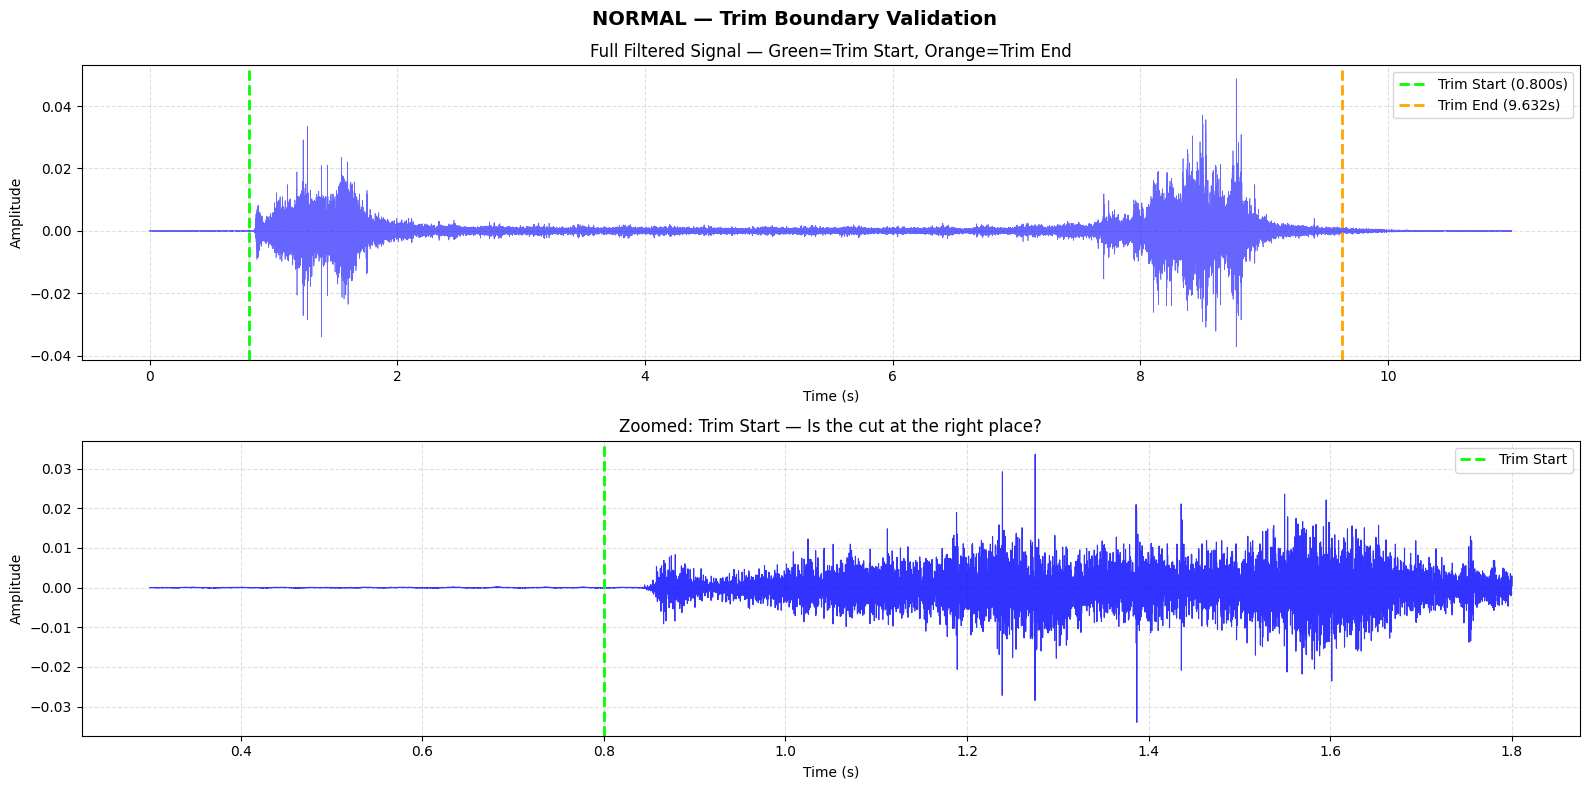

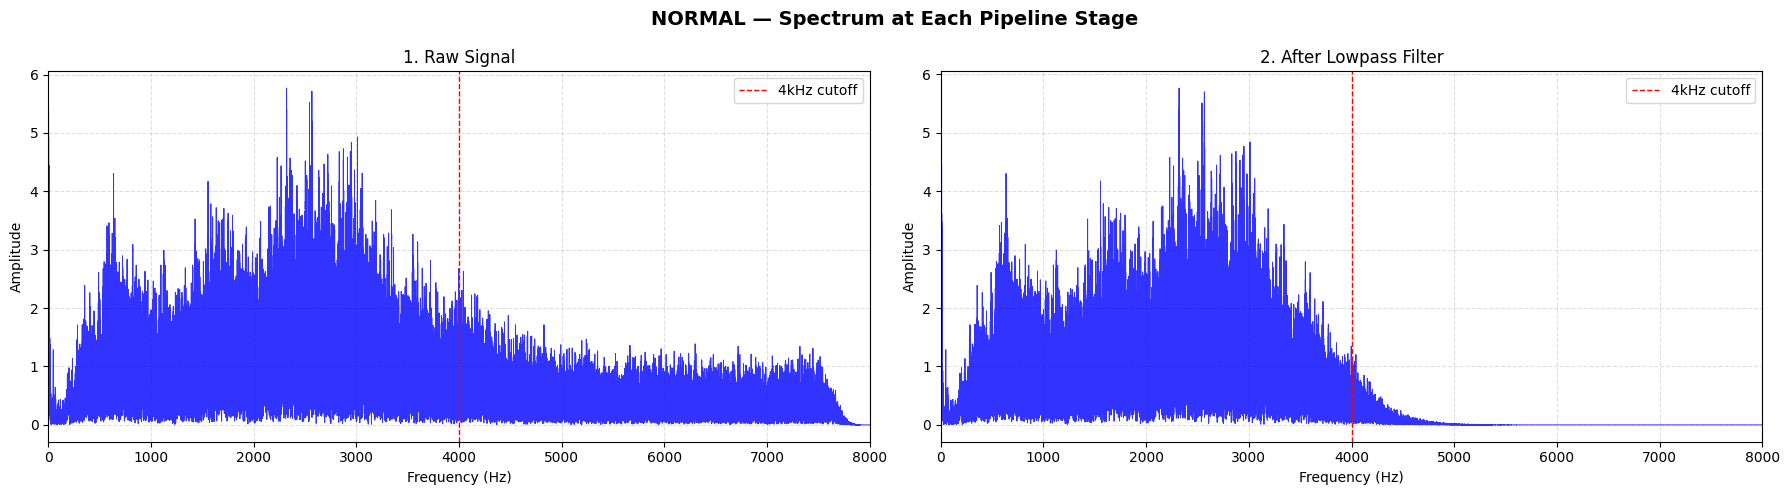

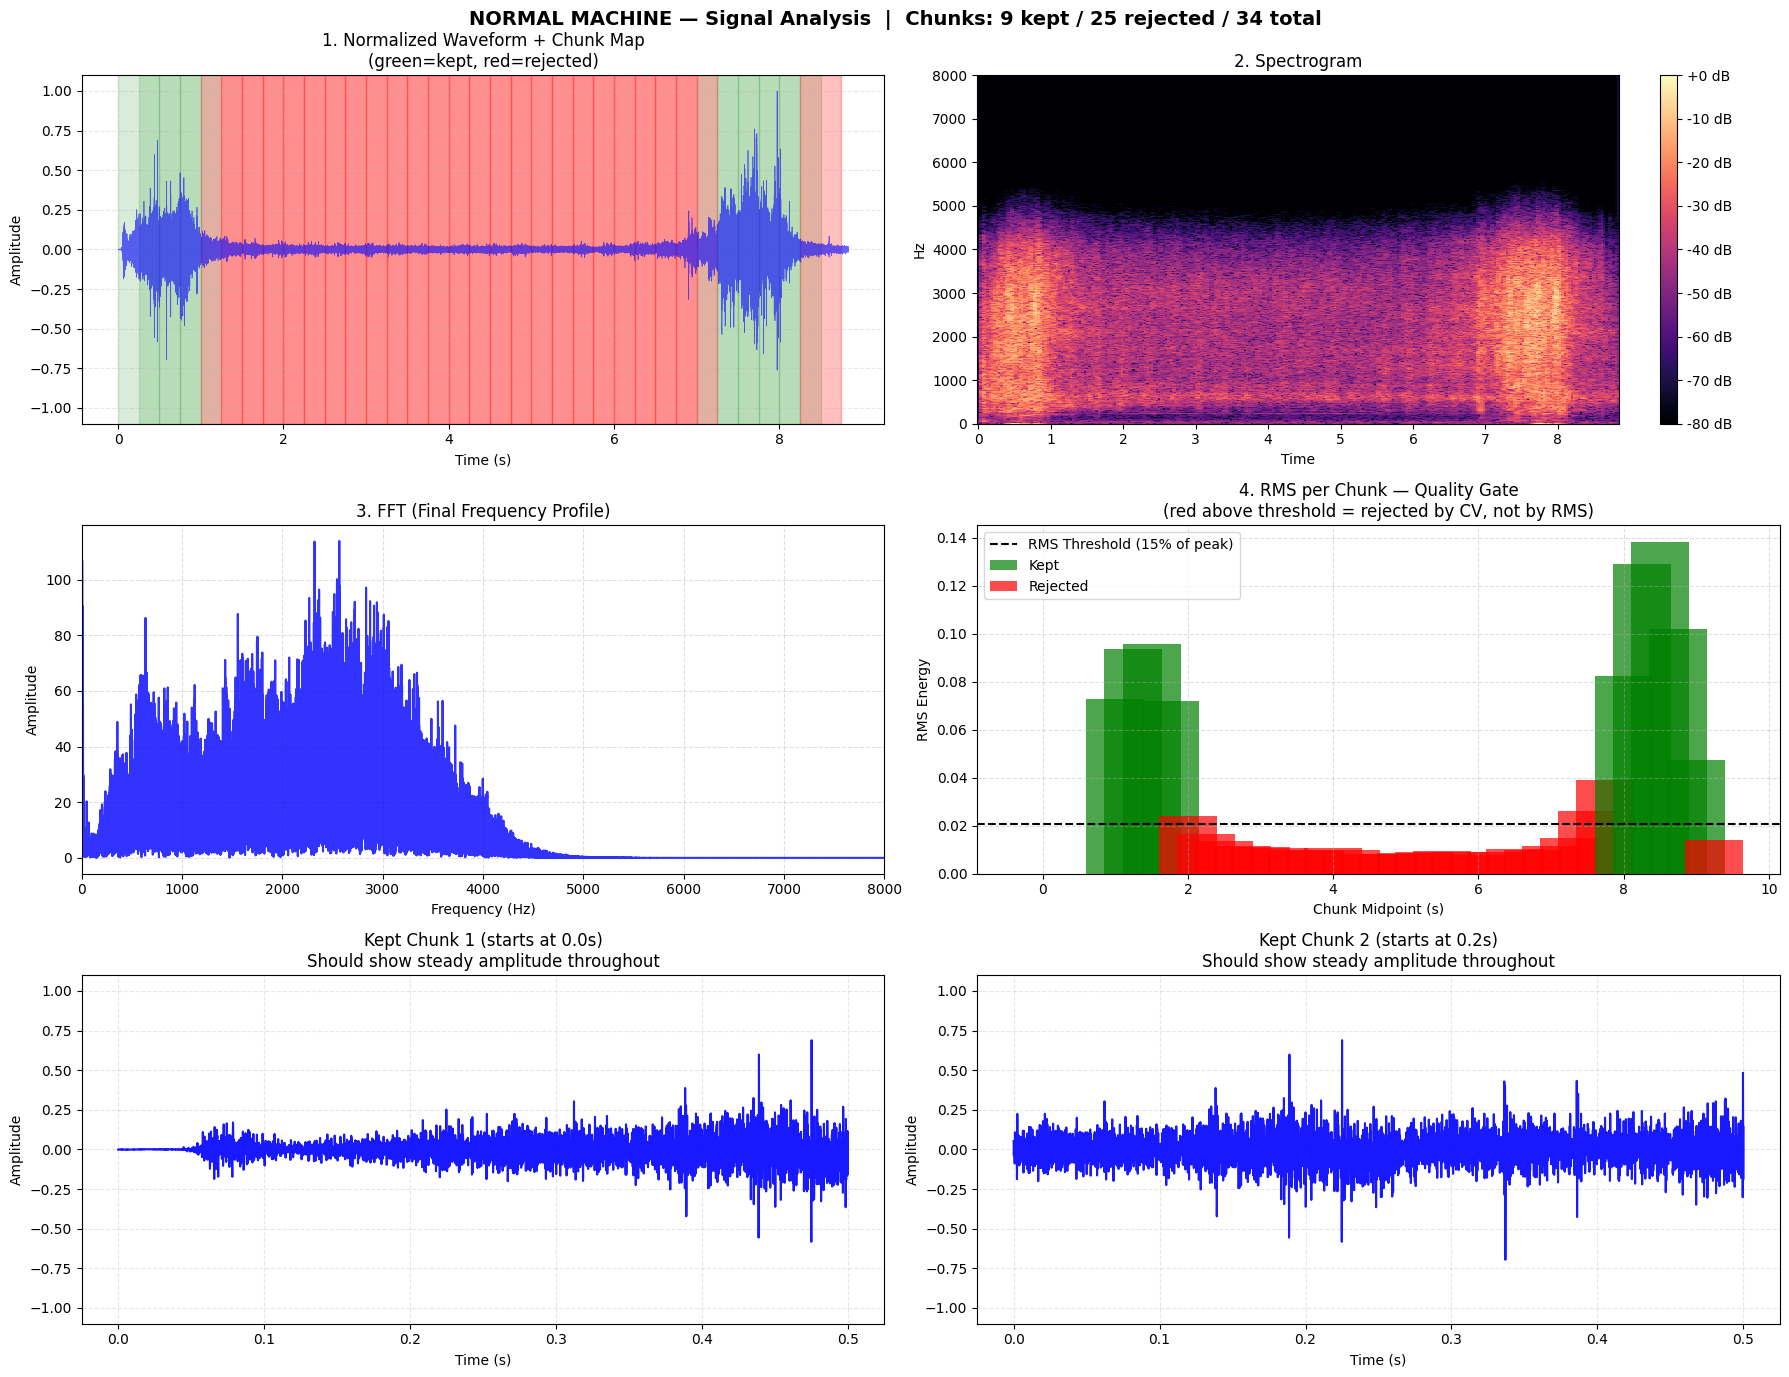

In [27]:
import librosa
import librosa.display
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import random

# ============================================================
# --- 1. ENGINEERING TOOLS ---
# ============================================================

def remove_dc_offset(y):
    """
    Subtracts the mean of the signal from every sample.
    
    A DC offset is a constant bias in the waveform caused by
    microphone/sensor imperfections. Mathematically:
    
        y_clean[n] = y[n] - mean(y)
    
    Without this, the FFT produces a spike at 0Hz that pollutes
    the entire frequency analysis. One line, costs nothing.
    """
    return y - np.mean(y)


'''def apply_preemphasis(y, coeff=0.97):
    """
    Applies a first-order high-shelf filter to flatten the spectrum.
    
    Difference equation:
        y[n] = x[n] - coeff * x[n-1]
    
    This computes the difference between consecutive samples.
    Rapidly changing signal (high frequency) → large difference → survives.
    Slowly changing signal (low frequency)   → small difference → suppressed.
    
    Transfer function: H(z) = 1 - coeff * z^(-1)
    Magnitude response: |H(f)| = sqrt(1 + coeff² - 2*coeff*cos(2πf/sr))
    
    At f=0Hz    → gain = 1 - coeff = 0.03  (low freq nearly killed)
    At f=8000Hz → gain = 1 + coeff = 1.97  (high freq nearly doubled)
    
    Why coeff=0.97:
    The -3dB point lands at ~120Hz, meaning everything above 120Hz
    (all your mechanical grinding frequencies 300Hz-4kHz) gets boosted.
    Sub-120Hz rumble gets suppressed. Standard value for audio DSP.
    
    np.append handles the boundary: first sample has no previous sample,
    so we keep it unchanged.
    """
    return np.append(y[0], y[1:] - coeff * y[:-1])'''


def apply_lowpass_filter(y, cutoff=4000, sr=16000, order=5):
    """
    5th-order Butterworth low-pass filter, zero-phase (filtfilt).
    
    Kills everything above 4kHz — validated by FFT analysis across
    150 files showing no meaningful signal above this cutoff.
    
    filtfilt applies the filter forward then backward, which:
    - Doubles the effective filter order (5th order → 10th order roll-off)
    - Eliminates phase distortion (zero-phase)
    
    Roll-off: ~30dB/octave (5th order Butterworth), meaning frequencies
    just above 4kHz are strongly attenuated without ringing artifacts.
    
    Order of operations matters: pre-emphasis boosted high frequencies,
    then this filter cuts them back above 4kHz. The net effect is a
    flattened spectrum from 120Hz to 4kHz, with clean cutoff above.
    """
    nyquist = 0.5 * sr
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, y)


def apply_trim(y, top_db=26, frame_length=512, hop_length=128):
    """
    Removes leading and trailing silence using librosa's energy-based trim.
    
    top_db=26 means: cut any region whose energy is more than 26dB
    below the peak energy of the file.
    
    26dB in linear scale:
        threshold = peak_amplitude / 10^(26/20) ≈ peak / 20 ≈ 5% of peak
    
    Why trim AFTER filtering and pre-emphasis:
    If you trimmed the raw signal, the silence threshold would be measured
    against unfiltered noise, giving inconsistent cut points across files.
    Trimming the clean signal gives consistent, reliable boundaries.
    
    Returns both the trimmed audio AND the trim indices so we can
    visualize exactly where the cuts happened.
    """
    y_trimmed, trim_indices = librosa.effects.trim(y, top_db=top_db)
    return y_trimmed, trim_indices


def apply_peak_normalization(y):
    """
    Scales the entire trimmed signal so its peak amplitude = 1.0.
    
        y_norm[n] = y[n] / max(|y[n]|)
    
    Why per-file (not per-chunk):
    If you normalize per chunk, you destroy the relative energy differences
    between chunks within the same file — a quiet ramp-up chunk would be
    scaled up to match a loud steady-state chunk, making them look identical.
    
    Normalizing per file preserves the relative loudness between chunks
    while ensuring all files sit on the same amplitude scale regardless of
    microphone distance or recording gain.
    
    The 1e-9 prevents division by zero on silent files.
    """
    peak = np.max(np.abs(y))
    return y / (peak + 1e-9)


def extract_sliding_windows(y, sr, chunk_sec=0.5, overlap_sec=0.25):
    """
    Segments the trimmed, normalized signal into overlapping fixed-length chunks.
    
    Parameters:
        chunk_sec=0.5  → each chunk is exactly 0.5 second = 8,000 samples at sr=16000
        overlap_sec=0.25 → chunks start every 0.25 seconds (50% overlap)
    
    Step size = chunk_sec - overlap_sec = 0.25 second = 4,000 samples
    
    For a 9.5s file:
        Chunk 1: 0.0s → 0.5s
        Chunk 2: 0.25s → 0.75s
        Chunk 3: 0.5s → 1.0s
        ...
        Chunk 18: 8.5s → 9.5s   ← last full chunk that fits
    
    The final incomplete chunk is dropped (range condition ensures this).
    start positions are tracked so we know where each chunk lives in
    the parent file — needed for the quality gate visualization and
    for the chunk naming convention later.
    """
    chunk_samples = int(chunk_sec * sr)
    step_samples  = int((chunk_sec - overlap_sec) * sr)
    chunks, starts = [], []
    for start in range(0, len(y) - chunk_samples + 1, step_samples):
        chunks.append(y[start:start + chunk_samples])
        starts.append(start)
    return chunks, starts


# ============================================================
# --- 2. CV QUALITY GATE ---
# ============================================================

def compute_rms(chunk):
    """
    Root Mean Square — single number representing average loudness.
    
        RMS = sqrt( mean( x[n]² ) )
    
    Squaring makes all values positive and penalizes large deviations.
    Square root brings it back to the same units as the original signal.
    """
    return np.sqrt(np.mean(chunk ** 2))


def is_uneven_chunk(chunk, n_windows=8, cv_threshold=1.2):
    """
    Coefficient of Variation (CV) based steady-state detector.
    
    Step 1: Split chunk into n_windows equal windows (8 × 250ms for 2s chunk)
    Step 2: Compute RMS of each window → [RMS_1, RMS_2, ..., RMS_8]
    Step 3: CV = std(RMS values) / mean(RMS values)
    
    CV measures RELATIVE variation — how uneven the energy is as a
    proportion of the average energy level. This makes it scale-independent:
    a loud ramp and a quiet ramp both get high CV,
    a loud steady chunk and a quiet steady chunk both get low CV.
    
    Why not just use std(RMS)?
    std is scale-dependent. A loud ramp has large std simply because
    it's loud. CV divides out the scale, leaving only the unevenness.
    
    cv_threshold=1.0 means: reject if std of window RMS values exceeds
    100% of their mean. This catches:
        - Ramp-up   (quiet start, loud end)
        - Ramp-down (loud start, quiet end)
        - Dropouts  (sudden silence mid-chunk)
        - Impacts   (sudden spike mid-chunk)
        - Any other energy inconsistency regardless of shape or position
    
    It is a general steady-state detector, not a ramp-specific detector.
    """
    window_size = len(chunk) // n_windows
    rms_values  = np.array([
        compute_rms(chunk[i * window_size:(i + 1) * window_size])
        for i in range(n_windows)
    ])
    
    mean_rms = rms_values.mean()
    if mean_rms == 0:
        return True  # fully silent chunk → always reject
    
    cv = rms_values.std() / mean_rms
    return cv > cv_threshold


def filter_chunks_by_quality(chunks, starts,
                              rms_threshold_ratio=0.30,
                              cv_threshold=1.2):
    """
    Two-stage quality gate applied to every chunk:
    
    Gate 1 — Global RMS threshold:
        Reject if chunk RMS < 15% of the loudest chunk's RMS.
        Catches fully silent or near-silent chunks that somehow
        survived trimming.
    
    Gate 2 — CV steady-state check:
        Reject if the chunk's energy is not consistent throughout.
        Catches ramps, dropouts, impacts, and any transient events.
    
    A chunk must PASS BOTH gates to be kept.
    Chunks that fail either gate are tracked separately so they can
    be visualized — you need to see what's being rejected and why.
    """
    rms_values = np.array([compute_rms(c) for c in chunks])
    peak_rms   = rms_values.max()
    threshold  = peak_rms * rms_threshold_ratio
    
    kept_chunks,     kept_starts,     kept_rms     = [], [], []
    rejected_chunks, rejected_starts, rejected_rms = [], [], []
    
    for chunk, start, rms in zip(chunks, starts, rms_values):
        too_quiet  = rms < threshold
        too_uneven = is_uneven_chunk(chunk, cv_threshold=cv_threshold)
        
        if not too_quiet and not too_uneven:
            kept_chunks.append(chunk)
            kept_starts.append(start)
            kept_rms.append(rms)
        else:
            rejected_chunks.append(chunk)
            rejected_starts.append(start)
            rejected_rms.append(rms)
    
    return (kept_chunks,     kept_starts,     kept_rms,
            rejected_chunks, rejected_starts, rejected_rms)


# ============================================================
# --- 3. MASTER PROCESS FUNCTION ---
# ============================================================

def process_and_chunk(file_path, sr=16000,
                      rms_threshold_ratio=0.30,
                      cv_threshold=1.2):
    """
    Full pipeline for one audio file. Returns a dict containing
    every intermediate stage so any step can be inspected or plotted.
    
    Pipeline order:
        Load
        → DC Offset Removal     (remove microphone bias)
        → Pre-emphasis          (flatten spectrum)
        → Lowpass Filter @4kHz  (remove high-freq hiss)
        → Trim                  (cut silence on clean signal)
        → Peak Normalize        (equalize volume across files)
        → Sliding Window        (produce fixed-length chunks)
        → CV Quality Gate       (reject unsteady chunks)
    """
    # Step 0: Load
    y_raw, _ = librosa.load(file_path, sr=sr)
    
    # Step 1: DC offset removal
    y_dc = remove_dc_offset(y_raw)
    
    # Step 2: Pre-emphasis
    #y_pre = apply_preemphasis(y_dc, coeff=0.97)
    
    # Step 3: Lowpass filter
    y_filtered = apply_lowpass_filter(y_dc, cutoff=4000, sr=sr)
    
    # Step 4: Trim
    y_trimmed, trim_indices = apply_trim(y_filtered, top_db=26, frame_length=512, hop_length=128)
    trim_start_sec = trim_indices[0] / sr
    trim_end_sec   = trim_indices[1] / sr
    
    # Step 5: Peak normalize — on the full trimmed file, not per chunk
    y_normalized = apply_peak_normalization(y_trimmed)
    
    # Step 6: Sliding window
    chunks, starts = extract_sliding_windows(
        y_normalized, sr, chunk_sec=0.5, overlap_sec=0.25
    )
    
    # Step 7: CV quality gate
    (kept_chunks,     kept_starts,     kept_rms,
     rejected_chunks, rejected_starts, rejected_rms) = filter_chunks_by_quality(
        chunks, starts,
        rms_threshold_ratio=rms_threshold_ratio,
        cv_threshold=cv_threshold
    )
    
    return {
        # Every pipeline stage preserved for inspection
        "raw":              y_raw,
        "dc_removed":       y_dc,
       # "preemphasized":    y_pre,
        "filtered":         y_filtered,
        "trimmed":          y_trimmed,
        "normalized":       y_normalized,
        "trim_start_sec":   trim_start_sec,
        "trim_end_sec":     trim_end_sec,
        # Chunk data
        "all_chunks":       chunks,
        "all_starts":       starts,
        "kept_chunks":      kept_chunks,
        "kept_starts":      kept_starts,
        "kept_rms":         kept_rms,
        "rejected_chunks":  rejected_chunks,
        "rejected_starts":  rejected_starts,
        "rejected_rms":     rejected_rms,
    }


# ============================================================
# --- 4. TRIM BOUNDARY VALIDATION PLOT ---
# ============================================================

def plot_trim_validation(result, sr, title_prefix, color):
    """
    Validates that top_db=26 is cutting at the right place.
    
    Top plot:    full filtered signal with trim boundaries marked
    Bottom plot: zoomed into the trim start region for precise inspection
    
    What to look for:
    - Everything LEFT of green line should be flat/near-zero
    - Signal should begin immediately RIGHT of green line
    - If signal starts before green line → top_db too aggressive (raise it)
    - If flat region exists after green line → top_db too loose (lower it)
    """
    fig, axes = plt.subplots(2, 1, figsize=(16, 8))
    fig.suptitle(f"{title_prefix} — Trim Boundary Validation",
                 fontsize=14, fontweight='bold')
    
    y_filt    = result["filtered"]
    time_full = np.linspace(0, len(y_filt) / sr, len(y_filt))
    
    # Top: full signal
    ax = axes[0]
    ax.plot(time_full, y_filt, color=color, alpha=0.6, linewidth=0.5)
    ax.axvline(result["trim_start_sec"], color='lime',   linewidth=2,
               linestyle='--', label=f'Trim Start ({result["trim_start_sec"]:.3f}s)')
    ax.axvline(result["trim_end_sec"],   color='orange', linewidth=2,
               linestyle='--', label=f'Trim End ({result["trim_end_sec"]:.3f}s)')
    ax.set_title("Full Filtered Signal — Green=Trim Start, Orange=Trim End")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)
    
    # Bottom: zoomed into trim start
    ax2        = axes[1]
    zoom_start = max(0, result["trim_start_sec"] - 0.5)
    zoom_end   = zoom_start + 1.5
    zoom_s     = int(zoom_start * sr)
    zoom_e     = int(zoom_end   * sr)
    y_zoom     = y_filt[zoom_s:zoom_e]
    t_zoom     = np.linspace(zoom_start, zoom_end, len(y_zoom))
    
    ax2.plot(t_zoom, y_zoom, color=color, alpha=0.8, linewidth=0.8)
    ax2.axvline(result["trim_start_sec"], color='lime', linewidth=2,
                linestyle='--', label='Trim Start')
    ax2.set_title("Zoomed: Trim Start — Is the cut at the right place?")
    ax2.set_xlabel("Time (s)")
    ax2.set_ylabel("Amplitude")
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.show()


# ============================================================
# --- 5. SPECTRUM COMPARISON PLOT ---
# ============================================================

def plot_spectrum_stages(result, sr, title_prefix, color):
    """
    Plots FFT at three pipeline stages side by side:
        1. Raw signal         → shows original spectrum with DC and hiss
        2. After pre-emphasis → shows flattened spectrum before filtering
        3. After filtering    → shows final clean spectrum fed into trim
    
    This is how you visually confirm that pre-emphasis and the
    lowpass filter are doing what the math says they should do.
    
    What to look for:
    - Stage 1→2: low frequencies should drop, high frequencies should rise
    - Stage 2→3: clean cutoff at 4kHz, nothing above it
    """
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    fig.suptitle(f"{title_prefix} — Spectrum at Each Pipeline Stage",
                 fontsize=14, fontweight='bold')
    
    stages = [
        (result["raw"],       "1. Raw Signal"),
        #(result["preemphasized"], "2. After Pre-emphasis"),
        (result["filtered"],  "2. After Lowpass Filter"),
    ]
    
    for ax, (signal, stage_title) in zip(axes, stages):
        n       = len(signal)
        spectrum = np.abs(np.fft.fft(signal))[:n // 2]
        freqs    = np.fft.fftfreq(n, 1 / sr)[:n // 2]
        ax.plot(freqs, spectrum, color=color, alpha=0.8, linewidth=0.7)
        ax.set_title(stage_title)
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Amplitude")
        ax.set_xlim(0, 8000)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.axvline(4000, color='red', linestyle='--',
                   linewidth=1, label='4kHz cutoff')
        ax.legend()
    
    plt.tight_layout()
    plt.show()


# ============================================================
# --- 6. MAIN DASHBOARD ---
# ============================================================

def plot_comprehensive_analysis(result, sr, title_prefix, color):
    """
    Six-panel dashboard showing the full pipeline output for one file.
    
    Panel 1: Trimmed normalized waveform with chunk map
             Green spans = kept chunks, Red spans = rejected chunks
             Lets you see spatially which chunks were rejected and where
    
    Panel 2: Spectrogram of the normalized signal
             Time vs Frequency vs Amplitude in dB
             Should show hard black above 5kHz (filter working)
    
    Panel 3: FFT of the normalized signal
             Final frequency profile after all processing
    
    Panel 4: RMS bar chart per chunk
             Each bar = one chunk, colored green (kept) or red (rejected)
             Dashed line = the 15% RMS threshold
             CV rejections show up here as red bars ABOVE the threshold
             (rejected not because too quiet but because too uneven)
    
    Panel 5: First kept chunk waveform
    Panel 6: Second kept chunk waveform
             These should look like steady-state grinding — no ramps,
             no dropouts, consistent amplitude throughout
    """
    kept  = result["kept_chunks"]
    full  = result["normalized"]
    n_kept  = len(kept)
    n_rej   = len(result["rejected_chunks"])
    n_total = n_kept + n_rej
    
    fig = plt.figure(figsize=(18, 14))
    fig.suptitle(
        f"{title_prefix} — Signal Analysis  |  "
        f"Chunks: {n_kept} kept / {n_rej} rejected / {n_total} total",
        fontsize=14, fontweight='bold'
    )
    
    max_amp       = np.max(np.abs(full)) * 1.1
    chunk_samples = int(0.5 * sr)
    
    # --- Panel 1: Waveform + chunk map ---
    ax1       = plt.subplot(3, 2, 1)
    time_full = np.linspace(0, len(full) / sr, len(full))
    ax1.plot(time_full, full, color=color, alpha=0.6, linewidth=0.5)
    
    for start in result["kept_starts"]:
        ax1.axvspan(start / sr, (start + chunk_samples) / sr,
                    alpha=0.15, color='green')
    for start in result["rejected_starts"]:
        ax1.axvspan(start / sr, (start + chunk_samples) / sr,
                    alpha=0.25, color='red')
    
    ax1.set_title("1. Normalized Waveform + Chunk Map\n(green=kept, red=rejected)")
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Amplitude")
    ax1.set_ylim(-max_amp, max_amp)
    ax1.grid(True, linestyle='--', alpha=0.3)
    
    # --- Panel 2: Spectrogram ---
    ax2  = plt.subplot(3, 2, 2)
    D    = np.abs(librosa.stft(full))
    DB   = librosa.amplitude_to_db(D, ref=np.max)
    img  = librosa.display.specshow(DB, sr=sr, x_axis='time',
                                    y_axis='hz', ax=ax2, cmap='magma')
    ax2.set_title("2. Spectrogram")
    ax2.set_ylim(0, 8000)
    fig.colorbar(img, ax=ax2, format="%+2.0f dB")
    
    # --- Panel 3: FFT ---
    ax3      = plt.subplot(3, 2, 3)
    spectrum = np.abs(np.fft.fft(full))
    freqs    = np.fft.fftfreq(len(full), 1 / sr)
    half_n   = len(full) // 2
    ax3.plot(freqs[:half_n], spectrum[:half_n], color=color, alpha=0.8)
    ax3.set_title("3. FFT (Final Frequency Profile)")
    ax3.set_xlabel("Frequency (Hz)")
    ax3.set_ylabel("Amplitude")
    ax3.set_xlim(0, 8000)
    ax3.grid(True, linestyle='--', alpha=0.4)
    
    # --- Panel 4: RMS bar chart with CV rejection visibility ---
    ax4        = plt.subplot(3, 2, 4)
    all_starts = result["all_starts"]
    all_rms    = [compute_rms(c) for c in result["all_chunks"]]
    times_mid  = [(s + int(sr)) / sr for s in all_starts]
    kept_set   = set(result["kept_starts"])
    
    for t, r, s in zip(times_mid, all_rms, all_starts):
        bar_color = 'green' if s in kept_set else 'red'
        ax4.bar(t, r, width=0.8, color=bar_color, alpha=0.7)
    
    # RMS threshold line
    peak_rms  = max(all_rms)
    threshold = peak_rms * 0.15
    ax4.axhline(threshold, color='black', linestyle='--',
                linewidth=1.5, label='RMS Threshold (15% of peak)')
    
    # Dummy bars for legend
    ax4.bar(0, 0, color='green', alpha=0.7, label='Kept')
    ax4.bar(0, 0, color='red',   alpha=0.7, label='Rejected')
    ax4.set_title("4. RMS per Chunk — Quality Gate\n"
                  "(red above threshold = rejected by CV, not by RMS)")
    ax4.set_xlabel("Chunk Midpoint (s)")
    ax4.set_ylabel("RMS Energy")
    ax4.legend()
    ax4.grid(True, linestyle='--', alpha=0.4)
    
    # --- Panels 5 & 6: First two kept chunks ---
    for i in range(2):
        ax = plt.subplot(3, 2, i + 5)
        if i < len(kept):
            chunk     = kept[i]
            t         = np.linspace(0, len(chunk) / sr, len(chunk))
            start_sec = result["kept_starts"][i] / sr
            ax.plot(t, chunk, color=color, alpha=0.9)
            ax.set_title(f"Kept Chunk {i+1} (starts at {start_sec:.1f}s)\n"
                         f"Should show steady amplitude throughout")
        else:
            ax.set_title(f"Kept Chunk {i+1} — not enough chunks")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Amplitude")
        ax.set_ylim(-max_amp, max_amp)
        ax.grid(True, linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# ============================================================
# --- 7. RUN ON ONE FILE ---
# ============================================================

normal_dir = "H:/.shortcut-targets-by-id/1pFPnn7lbpxWVfOmrDEyvHxXp0_6GFB90/Students/Machine 2/machine_data/Normal"

sr = 16000
random.seed(0)

# Pick one random normal file
norm_file = os.path.join(normal_dir, random.choice(
    [f for f in os.listdir(normal_dir) if f.endswith('.wav')]
))

print(f"Processing: {os.path.basename(norm_file)}")

result = process_and_chunk(norm_file, sr=sr,
                           rms_threshold_ratio=0.30,
                           cv_threshold=1.2)

print(f"Chunks: {len(result['kept_chunks'])} kept / "
      f"{len(result['rejected_chunks'])} rejected / "
      f"{len(result['all_chunks'])} total")

# Plot 1: Trim validation
plot_trim_validation(result, sr, "NORMAL", "blue")

# Plot 2: Spectrum at each pipeline stage
# This confirms pre-emphasis and lowpass are working as expected
plot_spectrum_stages(result, sr, "NORMAL", "blue")

# Plot 3: Full dashboard
plot_comprehensive_analysis(result, sr, "NORMAL MACHINE", "blue")

LET'S SEE WHAT MACHINE 3 HAS


Analyzing 100 files in Normal...
Analyzing 100 files in Abnormal...


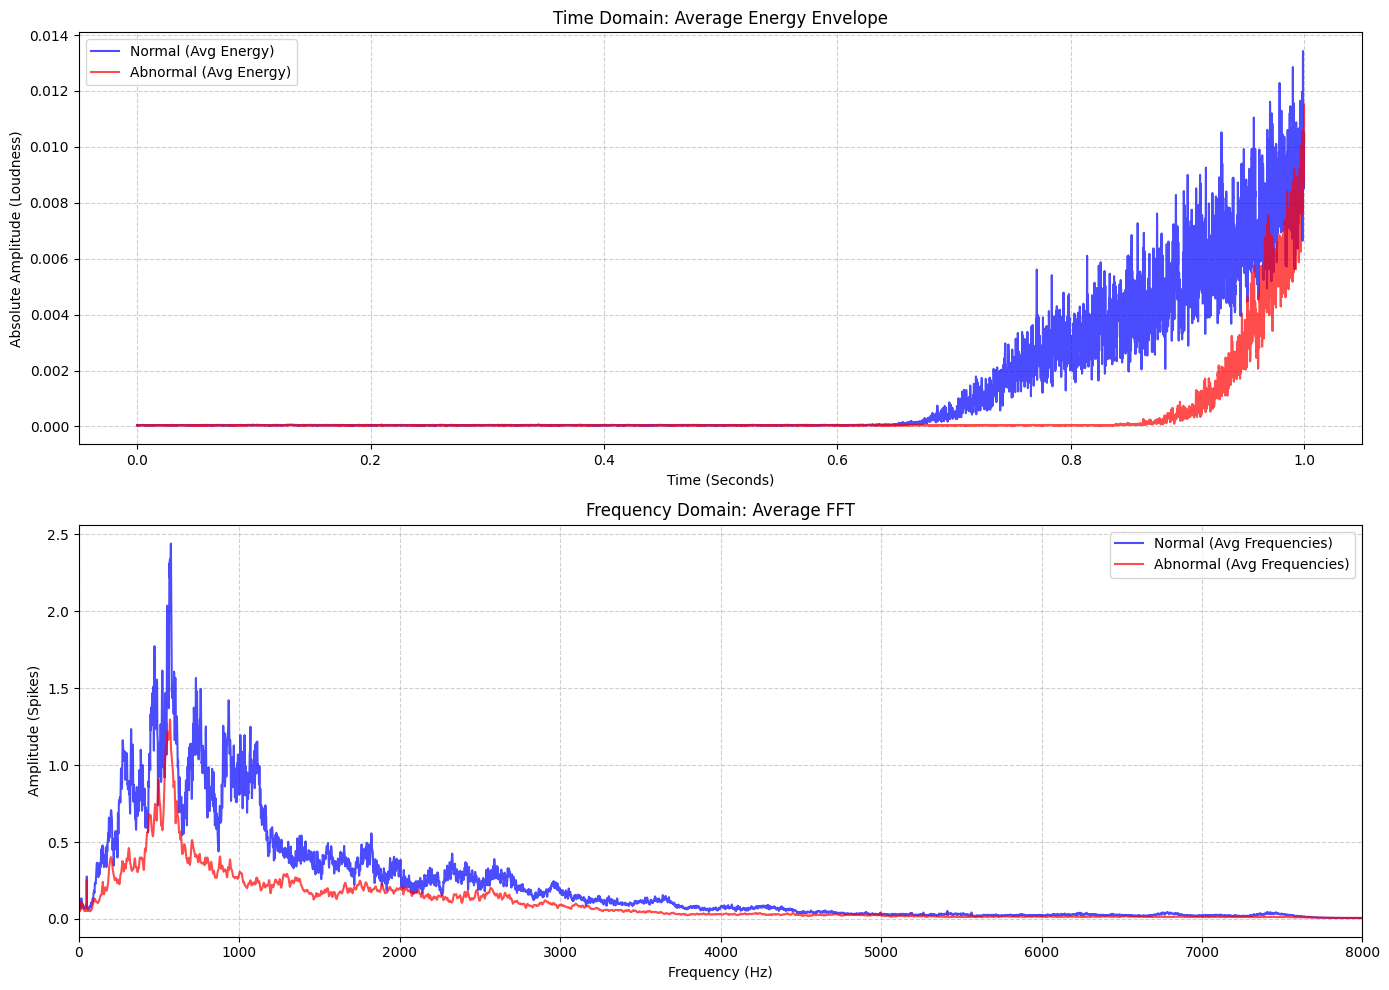

In [30]:
import librosa
import numpy as np
import os
import matplotlib.pyplot as plt

def compute_average_profiles(folder_path, num_files=150, target_sr=16000):
    """Calculates both the average frequency and average time profiles."""
    audio_files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
    
    np.random.shuffle(audio_files)
    audio_files = audio_files[:num_files]
    
    all_fft_amps = []
    all_time_amps = []
    
    print(f"Analyzing {len(audio_files)} files in {os.path.basename(folder_path)}...")
    
    for filename in audio_files:
        file_path = os.path.join(folder_path, filename)
        
        y, sr = librosa.load(file_path, sr=target_sr, duration=1.0)
        if len(y) < target_sr:
            y = np.pad(y, (0, target_sr - len(y)))
            
        # --- 1. FFT (Frequency) Processing ---
        spectrum = np.abs(np.fft.fft(y))
        half_point = len(spectrum) // 2
        pos_amps = spectrum[:half_point]
        all_fft_amps.append(pos_amps)
        
        # --- 2. Time (Amplitude) Processing ---
        # Crucial: Take the absolute value so waves don't cancel each other out!
        all_time_amps.append(np.abs(y))
        
    # Calculate the averages
    avg_fft = np.mean(all_fft_amps, axis=0)
    avg_time = np.mean(all_time_amps, axis=0)
    
    # Calculate X-axis labels
    freqs = np.fft.fftfreq(target_sr, 1/target_sr)[:half_point]
    times = np.linspace(0, 1.0, target_sr) # Creates a time axis from 0s to 1s
    
    return freqs, avg_fft, times, avg_time

# --- RUN THE ENGINE ---

normal_dir = "H:/.shortcut-targets-by-id/1pFPnn7lbpxWVfOmrDEyvHxXp0_6GFB90/Students/Machine 3/machine_data/Normal"
abnormal_dir = "H:/.shortcut-targets-by-id/1pFPnn7lbpxWVfOmrDEyvHxXp0_6GFB90/Students/Machine 3/machine_data/Abnormal"

# Get data for both
norm_freqs, norm_fft_avg, norm_times, norm_time_avg = compute_average_profiles(normal_dir, num_files=100)
ab_freqs, ab_fft_avg, ab_times, ab_time_avg = compute_average_profiles(abnormal_dir, num_files=100)

# --- PLOT BOTH GRAPHS ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# 1. The Time Graph (Amplitude Envelope)
ax1.plot(norm_times, norm_time_avg, label='Normal (Avg Energy)', color='blue', alpha=0.7)
ax1.plot(ab_times, ab_time_avg, label='Abnormal (Avg Energy)', color='red', alpha=0.7)
ax1.set_title('Time Domain: Average Energy Envelope')
ax1.set_xlabel('Time (Seconds)')
ax1.set_ylabel('Absolute Amplitude (Loudness)')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# 2. The Frequency Graph (FFT)
ax2.plot(norm_freqs, norm_fft_avg, label='Normal (Avg Frequencies)', color='blue', alpha=0.7)
ax2.plot(ab_freqs, ab_fft_avg, label='Abnormal (Avg Frequencies)', color='red', alpha=0.7)
ax2.set_title('Frequency Domain: Average FFT')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Amplitude (Spikes)')
ax2.set_xlim(0, 8000) # Nyquist limit for 16kHz
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

Processing: 8520.wav
Chunks: 33 kept / 0 rejected / 33 total


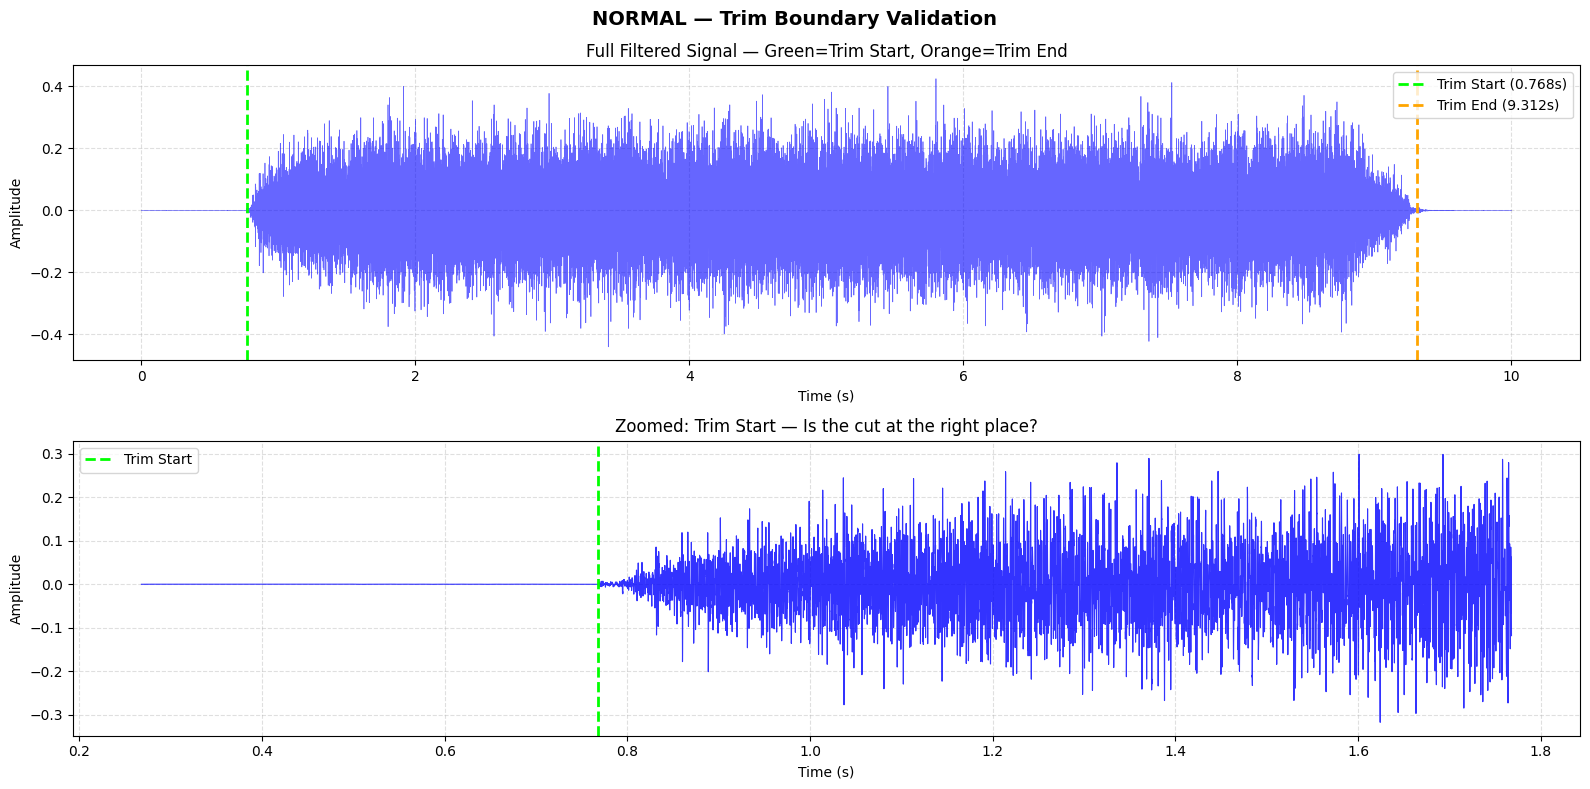

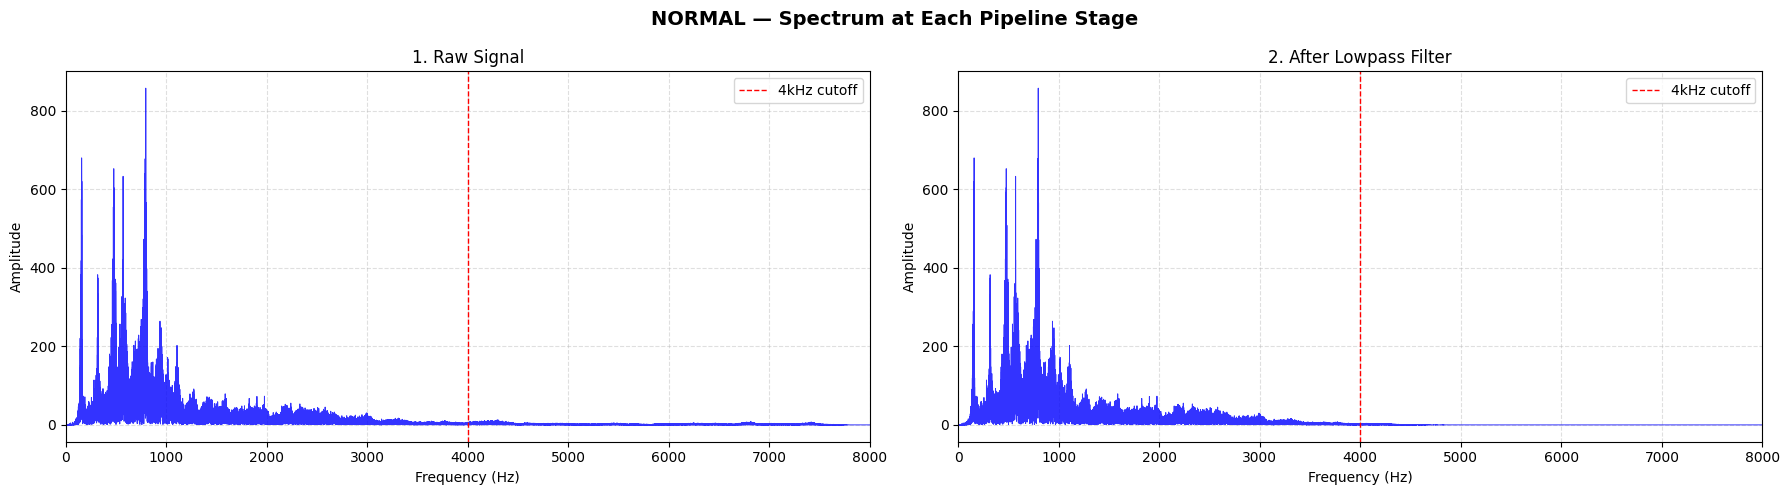

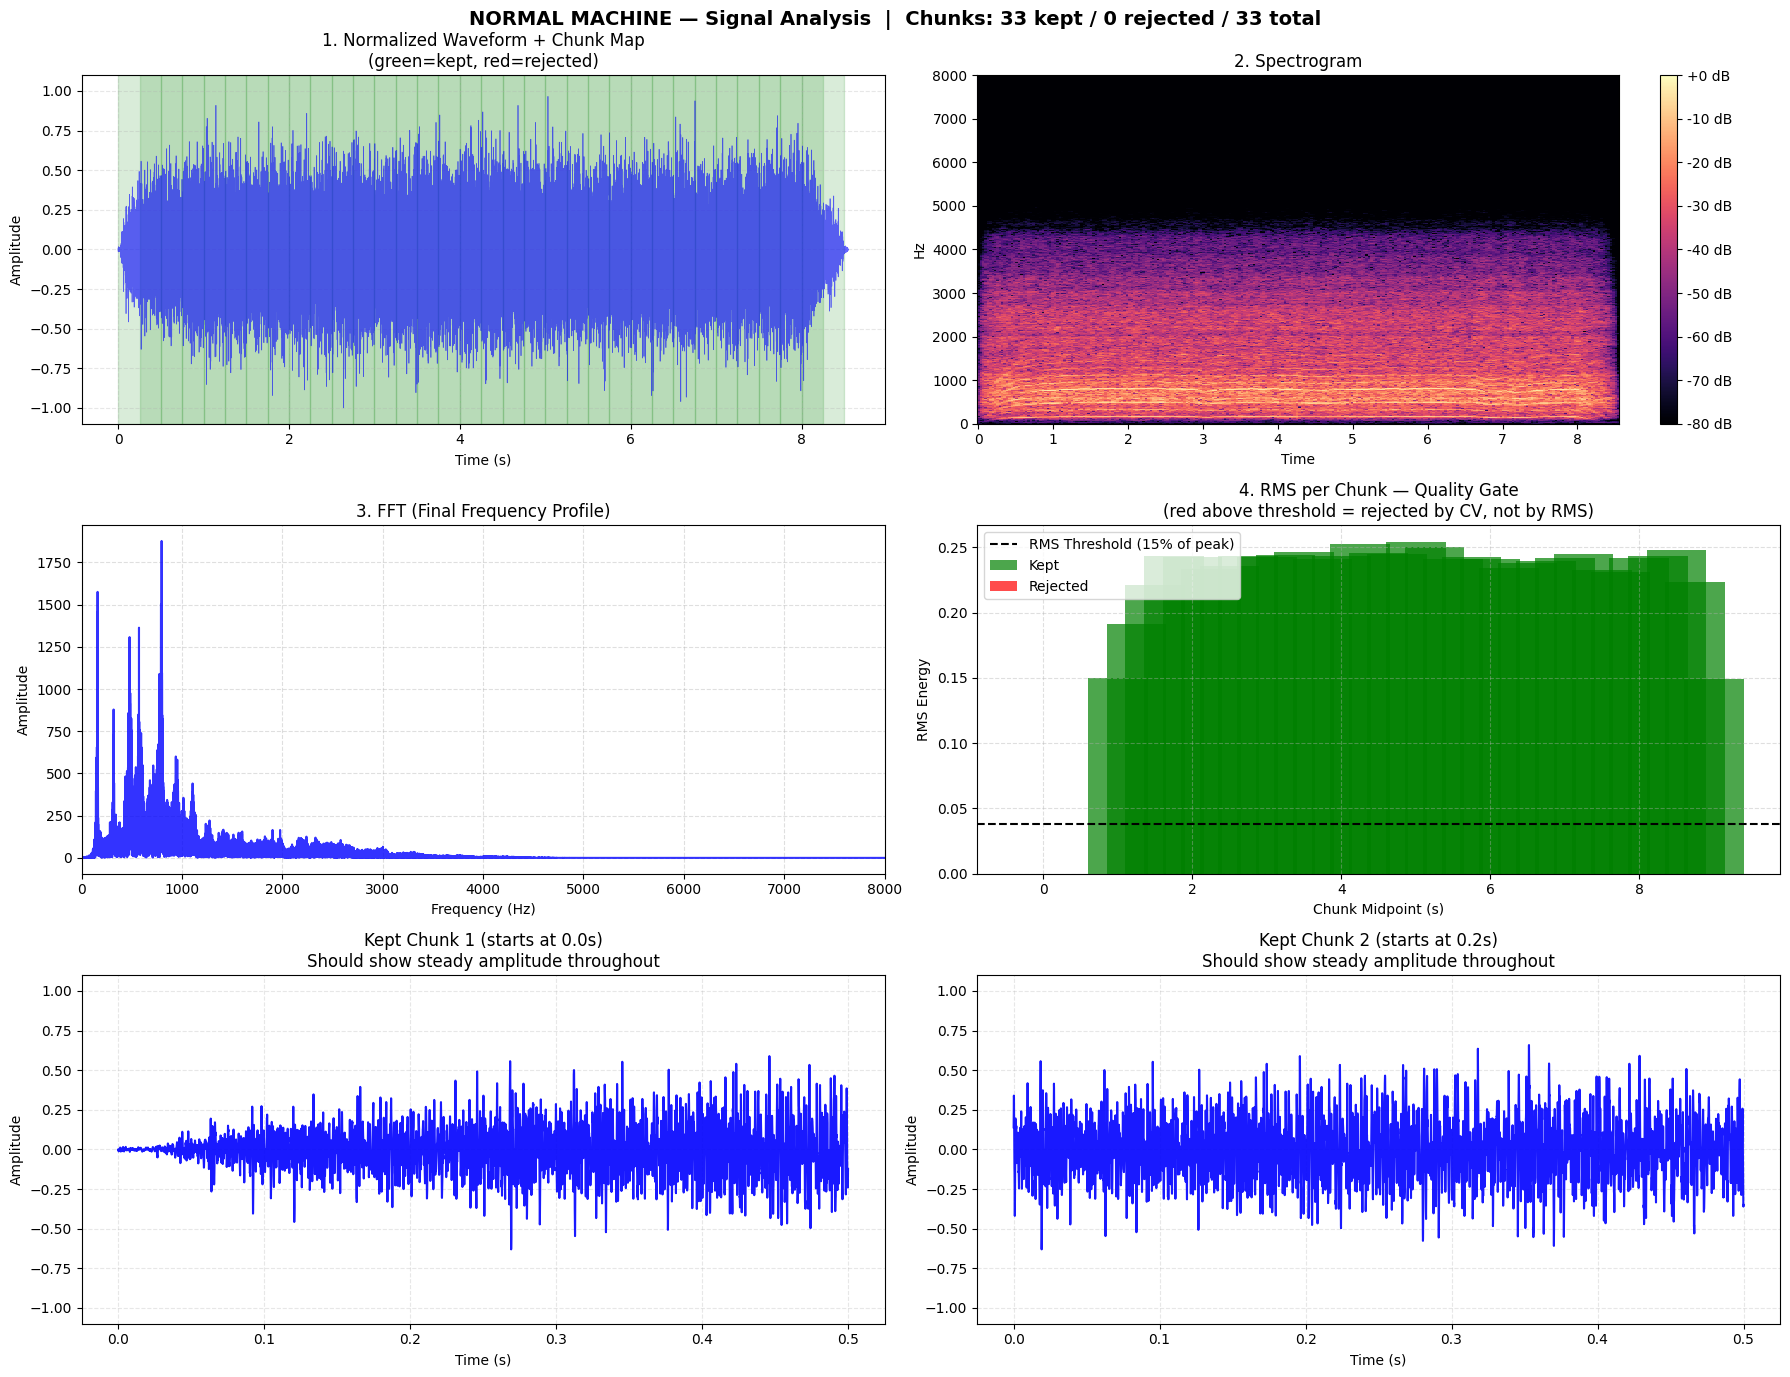

In [29]:
import librosa
import librosa.display
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import random

# ============================================================
# --- 1. ENGINEERING TOOLS ---
# ============================================================

def remove_dc_offset(y):
    """
    Subtracts the mean of the signal from every sample.
    
    A DC offset is a constant bias in the waveform caused by
    microphone/sensor imperfections. Mathematically:
    
        y_clean[n] = y[n] - mean(y)
    
    Without this, the FFT produces a spike at 0Hz that pollutes
    the entire frequency analysis. One line, costs nothing.
    """
    return y - np.mean(y)


'''def apply_preemphasis(y, coeff=0.97):
    """
    Applies a first-order high-shelf filter to flatten the spectrum.
    
    Difference equation:
        y[n] = x[n] - coeff * x[n-1]
    
    This computes the difference between consecutive samples.
    Rapidly changing signal (high frequency) → large difference → survives.
    Slowly changing signal (low frequency)   → small difference → suppressed.
    
    Transfer function: H(z) = 1 - coeff * z^(-1)
    Magnitude response: |H(f)| = sqrt(1 + coeff² - 2*coeff*cos(2πf/sr))
    
    At f=0Hz    → gain = 1 - coeff = 0.03  (low freq nearly killed)
    At f=8000Hz → gain = 1 + coeff = 1.97  (high freq nearly doubled)
    
    Why coeff=0.97:
    The -3dB point lands at ~120Hz, meaning everything above 120Hz
    (all your mechanical grinding frequencies 300Hz-4kHz) gets boosted.
    Sub-120Hz rumble gets suppressed. Standard value for audio DSP.
    
    np.append handles the boundary: first sample has no previous sample,
    so we keep it unchanged.
    """
    return np.append(y[0], y[1:] - coeff * y[:-1])'''


def apply_lowpass_filter(y, cutoff=4000, sr=16000, order=5):
    """
    5th-order Butterworth low-pass filter, zero-phase (filtfilt).
    
    Kills everything above 4kHz — validated by FFT analysis across
    150 files showing no meaningful signal above this cutoff.
    
    filtfilt applies the filter forward then backward, which:
    - Doubles the effective filter order (5th order → 10th order roll-off)
    - Eliminates phase distortion (zero-phase)
    
    Roll-off: ~30dB/octave (5th order Butterworth), meaning frequencies
    just above 4kHz are strongly attenuated without ringing artifacts.
    
    Order of operations matters: pre-emphasis boosted high frequencies,
    then this filter cuts them back above 4kHz. The net effect is a
    flattened spectrum from 120Hz to 4kHz, with clean cutoff above.
    """
    nyquist = 0.5 * sr
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, y)


def apply_trim(y, top_db=26, frame_length=512, hop_length=128):
    """
    Removes leading and trailing silence using librosa's energy-based trim.
    
    top_db=26 means: cut any region whose energy is more than 26dB
    below the peak energy of the file.
    
    26dB in linear scale:
        threshold = peak_amplitude / 10^(26/20) ≈ peak / 20 ≈ 5% of peak
    
    Why trim AFTER filtering and pre-emphasis:
    If you trimmed the raw signal, the silence threshold would be measured
    against unfiltered noise, giving inconsistent cut points across files.
    Trimming the clean signal gives consistent, reliable boundaries.
    
    Returns both the trimmed audio AND the trim indices so we can
    visualize exactly where the cuts happened.
    """
    y_trimmed, trim_indices = librosa.effects.trim(y, top_db=top_db)
    return y_trimmed, trim_indices


def apply_peak_normalization(y):
    """
    Scales the entire trimmed signal so its peak amplitude = 1.0.
    
        y_norm[n] = y[n] / max(|y[n]|)
    
    Why per-file (not per-chunk):
    If you normalize per chunk, you destroy the relative energy differences
    between chunks within the same file — a quiet ramp-up chunk would be
    scaled up to match a loud steady-state chunk, making them look identical.
    
    Normalizing per file preserves the relative loudness between chunks
    while ensuring all files sit on the same amplitude scale regardless of
    microphone distance or recording gain.
    
    The 1e-9 prevents division by zero on silent files.
    """
    peak = np.max(np.abs(y))
    return y / (peak + 1e-9)


def extract_sliding_windows(y, sr, chunk_sec=0.5, overlap_sec=0.25):
    """
    Segments the trimmed, normalized signal into overlapping fixed-length chunks.
    
    Parameters:
        chunk_sec=0.5  → each chunk is exactly 0.5 second = 8,000 samples at sr=16000
        overlap_sec=0.25 → chunks start every 0.25 seconds (50% overlap)
    
    Step size = chunk_sec - overlap_sec = 0.25 second = 4,000 samples
    
    For a 9.5s file:
        Chunk 1: 0.0s → 0.5s
        Chunk 2: 0.25s → 0.75s
        Chunk 3: 0.5s → 1.0s
        ...
        Chunk 18: 8.5s → 9.5s   ← last full chunk that fits
    
    The final incomplete chunk is dropped (range condition ensures this).
    start positions are tracked so we know where each chunk lives in
    the parent file — needed for the quality gate visualization and
    for the chunk naming convention later.
    """
    chunk_samples = int(chunk_sec * sr)
    step_samples  = int((chunk_sec - overlap_sec) * sr)
    chunks, starts = [], []
    for start in range(0, len(y) - chunk_samples + 1, step_samples):
        chunks.append(y[start:start + chunk_samples])
        starts.append(start)
    return chunks, starts


# ============================================================
# --- 2. CV QUALITY GATE ---
# ============================================================

def compute_rms(chunk):
    """
    Root Mean Square — single number representing average loudness.
    
        RMS = sqrt( mean( x[n]² ) )
    
    Squaring makes all values positive and penalizes large deviations.
    Square root brings it back to the same units as the original signal.
    """
    return np.sqrt(np.mean(chunk ** 2))


def is_uneven_chunk(chunk, n_windows=8, cv_threshold=0.8):
    """
    Coefficient of Variation (CV) based steady-state detector.
    
    Step 1: Split chunk into n_windows equal windows (8 × 250ms for 2s chunk)
    Step 2: Compute RMS of each window → [RMS_1, RMS_2, ..., RMS_8]
    Step 3: CV = std(RMS values) / mean(RMS values)
    
    CV measures RELATIVE variation — how uneven the energy is as a
    proportion of the average energy level. This makes it scale-independent:
    a loud ramp and a quiet ramp both get high CV,
    a loud steady chunk and a quiet steady chunk both get low CV.
    
    Why not just use std(RMS)?
    std is scale-dependent. A loud ramp has large std simply because
    it's loud. CV divides out the scale, leaving only the unevenness.
    
    cv_threshold=1.2 means: reject if std of window RMS values exceeds
    120% of their mean. This catches:
        - Ramp-up   (quiet start, loud end)
        - Ramp-down (loud start, quiet end)
        - Dropouts  (sudden silence mid-chunk)
        - Impacts   (sudden spike mid-chunk)
        - Any other energy inconsistency regardless of shape or position
    
    It is a general steady-state detector, not a ramp-specific detector.
    """
    window_size = len(chunk) // n_windows
    rms_values  = np.array([
        compute_rms(chunk[i * window_size:(i + 1) * window_size])
        for i in range(n_windows)
    ])
    
    mean_rms = rms_values.mean()
    if mean_rms == 0:
        return True  # fully silent chunk → always reject
    
    cv = rms_values.std() / mean_rms
    return cv > cv_threshold


def filter_chunks_by_quality(chunks, starts,
                              rms_threshold_ratio=0.30,
                              cv_threshold=1.2):
    """
    Two-stage quality gate applied to every chunk:
    
    Gate 1 — Global RMS threshold:
        Reject if chunk RMS < 20% of the loudest chunk's RMS.
        Catches fully silent or near-silent chunks that somehow
        survived trimming.
    
    Gate 2 — CV steady-state check:
        Reject if the chunk's energy is not consistent throughout.
        Catches ramps, dropouts, impacts, and any transient events.
    
    A chunk must PASS BOTH gates to be kept.
    Chunks that fail either gate are tracked separately so they can
    be visualized — you need to see what's being rejected and why.
    """
    rms_values = np.array([compute_rms(c) for c in chunks])
    peak_rms   = rms_values.max()
    threshold  = peak_rms * rms_threshold_ratio
    
    kept_chunks,     kept_starts,     kept_rms     = [], [], []
    rejected_chunks, rejected_starts, rejected_rms = [], [], []
    
    for chunk, start, rms in zip(chunks, starts, rms_values):
        too_quiet  = rms < threshold
        too_uneven = is_uneven_chunk(chunk, cv_threshold=cv_threshold)
        
        if not too_quiet and not too_uneven:
            kept_chunks.append(chunk)
            kept_starts.append(start)
            kept_rms.append(rms)
        else:
            rejected_chunks.append(chunk)
            rejected_starts.append(start)
            rejected_rms.append(rms)
    
    return (kept_chunks,     kept_starts,     kept_rms,
            rejected_chunks, rejected_starts, rejected_rms)


# ============================================================
# --- 3. MASTER PROCESS FUNCTION ---
# ============================================================

def process_and_chunk(file_path, sr=16000,
                      rms_threshold_ratio=0.30,
                      cv_threshold=1.2):
    """
    Full pipeline for one audio file. Returns a dict containing
    every intermediate stage so any step can be inspected or plotted.
    
    Pipeline order:
        Load
        → DC Offset Removal     (remove microphone bias)
        → Pre-emphasis          (flatten spectrum)
        → Lowpass Filter @4kHz  (remove high-freq hiss)
        → Trim                  (cut silence on clean signal)
        → Peak Normalize        (equalize volume across files)
        → Sliding Window        (produce fixed-length chunks)
        → CV Quality Gate       (reject unsteady chunks)
    """
    # Step 0: Load
    y_raw, _ = librosa.load(file_path, sr=sr)
    
    # Step 1: DC offset removal
    y_dc = remove_dc_offset(y_raw)
    
    # Step 2: Pre-emphasis
    #y_pre = apply_preemphasis(y_dc, coeff=0.97)
    
    # Step 3: Lowpass filter
    y_filtered = apply_lowpass_filter(y_dc, cutoff=4000, sr=sr)
    
    # Step 4: Trim
    y_trimmed, trim_indices = apply_trim(y_filtered, top_db=26, frame_length=512, hop_length=128)
    trim_start_sec = trim_indices[0] / sr
    trim_end_sec   = trim_indices[1] / sr
    
    # Step 5: Peak normalize — on the full trimmed file, not per chunk
    y_normalized = apply_peak_normalization(y_trimmed)
    
    # Step 6: Sliding window
    chunks, starts = extract_sliding_windows(
        y_normalized, sr, chunk_sec=0.5, overlap_sec=0.25
    )
    
    # Step 7: CV quality gate
    (kept_chunks,     kept_starts,     kept_rms,
     rejected_chunks, rejected_starts, rejected_rms) = filter_chunks_by_quality(
        chunks, starts,
        rms_threshold_ratio=rms_threshold_ratio,
        cv_threshold=cv_threshold
    )
    
    return {
        # Every pipeline stage preserved for inspection
        "raw":              y_raw,
        "dc_removed":       y_dc,
       # "preemphasized":    y_pre,
        "filtered":         y_filtered,
        "trimmed":          y_trimmed,
        "normalized":       y_normalized,
        "trim_start_sec":   trim_start_sec,
        "trim_end_sec":     trim_end_sec,
        # Chunk data
        "all_chunks":       chunks,
        "all_starts":       starts,
        "kept_chunks":      kept_chunks,
        "kept_starts":      kept_starts,
        "kept_rms":         kept_rms,
        "rejected_chunks":  rejected_chunks,
        "rejected_starts":  rejected_starts,
        "rejected_rms":     rejected_rms,
    }


# ============================================================
# --- 4. TRIM BOUNDARY VALIDATION PLOT ---
# ============================================================

def plot_trim_validation(result, sr, title_prefix, color):
    """
    Validates that top_db=26 is cutting at the right place.
    
    Top plot:    full filtered signal with trim boundaries marked
    Bottom plot: zoomed into the trim start region for precise inspection
    
    What to look for:
    - Everything LEFT of green line should be flat/near-zero
    - Signal should begin immediately RIGHT of green line
    - If signal starts before green line → top_db too aggressive (raise it)
    - If flat region exists after green line → top_db too loose (lower it)
    """
    fig, axes = plt.subplots(2, 1, figsize=(16, 8))
    fig.suptitle(f"{title_prefix} — Trim Boundary Validation",
                 fontsize=14, fontweight='bold')
    
    y_filt    = result["filtered"]
    time_full = np.linspace(0, len(y_filt) / sr, len(y_filt))
    
    # Top: full signal
    ax = axes[0]
    ax.plot(time_full, y_filt, color=color, alpha=0.6, linewidth=0.5)
    ax.axvline(result["trim_start_sec"], color='lime',   linewidth=2,
               linestyle='--', label=f'Trim Start ({result["trim_start_sec"]:.3f}s)')
    ax.axvline(result["trim_end_sec"],   color='orange', linewidth=2,
               linestyle='--', label=f'Trim End ({result["trim_end_sec"]:.3f}s)')
    ax.set_title("Full Filtered Signal — Green=Trim Start, Orange=Trim End")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)
    
    # Bottom: zoomed into trim start
    ax2        = axes[1]
    zoom_start = max(0, result["trim_start_sec"] - 0.5)
    zoom_end   = zoom_start + 1.5
    zoom_s     = int(zoom_start * sr)
    zoom_e     = int(zoom_end   * sr)
    y_zoom     = y_filt[zoom_s:zoom_e]
    t_zoom     = np.linspace(zoom_start, zoom_end, len(y_zoom))
    
    ax2.plot(t_zoom, y_zoom, color=color, alpha=0.8, linewidth=0.8)
    ax2.axvline(result["trim_start_sec"], color='lime', linewidth=2,
                linestyle='--', label='Trim Start')
    ax2.set_title("Zoomed: Trim Start — Is the cut at the right place?")
    ax2.set_xlabel("Time (s)")
    ax2.set_ylabel("Amplitude")
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.show()


# ============================================================
# --- 5. SPECTRUM COMPARISON PLOT ---
# ============================================================

def plot_spectrum_stages(result, sr, title_prefix, color):
    """
    Plots FFT at three pipeline stages side by side:
        1. Raw signal         → shows original spectrum with DC and hiss
        2. After pre-emphasis → shows flattened spectrum before filtering
        3. After filtering    → shows final clean spectrum fed into trim
    
    This is how you visually confirm that pre-emphasis and the
    lowpass filter are doing what the math says they should do.
    
    What to look for:
    - Stage 1→2: low frequencies should drop, high frequencies should rise
    - Stage 2→3: clean cutoff at 4kHz, nothing above it
    """
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    fig.suptitle(f"{title_prefix} — Spectrum at Each Pipeline Stage",
                 fontsize=14, fontweight='bold')
    
    stages = [
        (result["raw"],       "1. Raw Signal"),
        #(result["preemphasized"], "2. After Pre-emphasis"),
        (result["filtered"],  "2. After Lowpass Filter"),
    ]
    
    for ax, (signal, stage_title) in zip(axes, stages):
        n       = len(signal)
        spectrum = np.abs(np.fft.fft(signal))[:n // 2]
        freqs    = np.fft.fftfreq(n, 1 / sr)[:n // 2]
        ax.plot(freqs, spectrum, color=color, alpha=0.8, linewidth=0.7)
        ax.set_title(stage_title)
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Amplitude")
        ax.set_xlim(0, 8000)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.axvline(4000, color='red', linestyle='--',
                   linewidth=1, label='4kHz cutoff')
        ax.legend()
    
    plt.tight_layout()
    plt.show()


# ============================================================
# --- 6. MAIN DASHBOARD ---
# ============================================================

def plot_comprehensive_analysis(result, sr, title_prefix, color):
    """
    Six-panel dashboard showing the full pipeline output for one file.
    
    Panel 1: Trimmed normalized waveform with chunk map
             Green spans = kept chunks, Red spans = rejected chunks
             Lets you see spatially which chunks were rejected and where
    
    Panel 2: Spectrogram of the normalized signal
             Time vs Frequency vs Amplitude in dB
             Should show hard black above 5kHz (filter working)
    
    Panel 3: FFT of the normalized signal
             Final frequency profile after all processing
    
    Panel 4: RMS bar chart per chunk
             Each bar = one chunk, colored green (kept) or red (rejected)
             Dashed line = the 15% RMS threshold
             CV rejections show up here as red bars ABOVE the threshold
             (rejected not because too quiet but because too uneven)
    
    Panel 5: First kept chunk waveform
    Panel 6: Second kept chunk waveform
             These should look like steady-state grinding — no ramps,
             no dropouts, consistent amplitude throughout
    """
    kept  = result["kept_chunks"]
    full  = result["normalized"]
    n_kept  = len(kept)
    n_rej   = len(result["rejected_chunks"])
    n_total = n_kept + n_rej
    
    fig = plt.figure(figsize=(18, 14))
    fig.suptitle(
        f"{title_prefix} — Signal Analysis  |  "
        f"Chunks: {n_kept} kept / {n_rej} rejected / {n_total} total",
        fontsize=14, fontweight='bold'
    )
    
    max_amp       = np.max(np.abs(full)) * 1.1
    chunk_samples = int(0.5 * sr)
    
    # --- Panel 1: Waveform + chunk map ---
    ax1       = plt.subplot(3, 2, 1)
    time_full = np.linspace(0, len(full) / sr, len(full))
    ax1.plot(time_full, full, color=color, alpha=0.6, linewidth=0.5)
    
    for start in result["kept_starts"]:
        ax1.axvspan(start / sr, (start + chunk_samples) / sr,
                    alpha=0.15, color='green')
    for start in result["rejected_starts"]:
        ax1.axvspan(start / sr, (start + chunk_samples) / sr,
                    alpha=0.25, color='red')
    
    ax1.set_title("1. Normalized Waveform + Chunk Map\n(green=kept, red=rejected)")
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Amplitude")
    ax1.set_ylim(-max_amp, max_amp)
    ax1.grid(True, linestyle='--', alpha=0.3)
    
    # --- Panel 2: Spectrogram ---
    ax2  = plt.subplot(3, 2, 2)
    D    = np.abs(librosa.stft(full))
    DB   = librosa.amplitude_to_db(D, ref=np.max)
    img  = librosa.display.specshow(DB, sr=sr, x_axis='time',
                                    y_axis='hz', ax=ax2, cmap='magma')
    ax2.set_title("2. Spectrogram")
    ax2.set_ylim(0, 8000)
    fig.colorbar(img, ax=ax2, format="%+2.0f dB")
    
    # --- Panel 3: FFT ---
    ax3      = plt.subplot(3, 2, 3)
    spectrum = np.abs(np.fft.fft(full))
    freqs    = np.fft.fftfreq(len(full), 1 / sr)
    half_n   = len(full) // 2
    ax3.plot(freqs[:half_n], spectrum[:half_n], color=color, alpha=0.8)
    ax3.set_title("3. FFT (Final Frequency Profile)")
    ax3.set_xlabel("Frequency (Hz)")
    ax3.set_ylabel("Amplitude")
    ax3.set_xlim(0, 8000)
    ax3.grid(True, linestyle='--', alpha=0.4)
    
    # --- Panel 4: RMS bar chart with CV rejection visibility ---
    ax4        = plt.subplot(3, 2, 4)
    all_starts = result["all_starts"]
    all_rms    = [compute_rms(c) for c in result["all_chunks"]]
    times_mid  = [(s + int(sr)) / sr for s in all_starts]
    kept_set   = set(result["kept_starts"])
    
    for t, r, s in zip(times_mid, all_rms, all_starts):
        bar_color = 'green' if s in kept_set else 'red'
        ax4.bar(t, r, width=0.8, color=bar_color, alpha=0.7)
    
    # RMS threshold line
    peak_rms  = max(all_rms)
    threshold = peak_rms * 0.15
    ax4.axhline(threshold, color='black', linestyle='--',
                linewidth=1.5, label='RMS Threshold (15% of peak)')
    
    # Dummy bars for legend
    ax4.bar(0, 0, color='green', alpha=0.7, label='Kept')
    ax4.bar(0, 0, color='red',   alpha=0.7, label='Rejected')
    ax4.set_title("4. RMS per Chunk — Quality Gate\n"
                  "(red above threshold = rejected by CV, not by RMS)")
    ax4.set_xlabel("Chunk Midpoint (s)")
    ax4.set_ylabel("RMS Energy")
    ax4.legend()
    ax4.grid(True, linestyle='--', alpha=0.4)
    
    # --- Panels 5 & 6: First two kept chunks ---
    for i in range(2):
        ax = plt.subplot(3, 2, i + 5)
        if i < len(kept):
            chunk     = kept[i]
            t         = np.linspace(0, len(chunk) / sr, len(chunk))
            start_sec = result["kept_starts"][i] / sr
            ax.plot(t, chunk, color=color, alpha=0.9)
            ax.set_title(f"Kept Chunk {i+1} (starts at {start_sec:.1f}s)\n"
                         f"Should show steady amplitude throughout")
        else:
            ax.set_title(f"Kept Chunk {i+1} — not enough chunks")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Amplitude")
        ax.set_ylim(-max_amp, max_amp)
        ax.grid(True, linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# ============================================================
# --- 7. RUN ON ONE FILE ---
# ============================================================

normal_dir = "H:/.shortcut-targets-by-id/1pFPnn7lbpxWVfOmrDEyvHxXp0_6GFB90/Students/Machine 3/machine_data/Normal"

sr = 16000
random.seed(700)

# Pick one random normal file
norm_file = os.path.join(normal_dir, random.choice(
    [f for f in os.listdir(normal_dir) if f.endswith('.wav')]
))

print(f"Processing: {os.path.basename(norm_file)}")

result = process_and_chunk(norm_file, sr=sr,
                           rms_threshold_ratio=0.30,
                           cv_threshold=1.2)

print(f"Chunks: {len(result['kept_chunks'])} kept / "
      f"{len(result['rejected_chunks'])} rejected / "
      f"{len(result['all_chunks'])} total")

# Plot 1: Trim validation
plot_trim_validation(result, sr, "NORMAL", "blue")

# Plot 2: Spectrum at each pipeline stage
# This confirms pre-emphasis and lowpass are working as expected
plot_spectrum_stages(result, sr, "NORMAL", "blue")

# Plot 3: Full dashboard
plot_comprehensive_analysis(result, sr, "NORMAL MACHINE", "blue")

VERDICT

Our preprocessing strategy was designed to bridge the gap between the steady-state acoustics of Machines 1 and 3 and the impulsive, spike-heavy nature of Machine 2. While Machines 1 and 3 have smooth frequency profiles that could tolerate strict stability gates, those same settings would have eliminated the critical fault "spikes" of Machine 2, leading to a total loss of training data for that class. We resolved this Preprocessing Recall vs. Model Precision trade-off by prioritizing data survival; we implemented a high CV Threshold of 1.2 and an aggressive RMS Threshold of 0.30. This configuration ensures that even though some noise is introduced, the high-energy mechanical transients of Machine 2 are preserved. By using a 0.5s chunk size with 0.25s overlap, we maintain a consistent signal-to-noise ratio that allows our parallel CNN and Edge ML models to effectively distinguish machine faults from background artifacts.  